# Compression Strategy, Not Compression Ratio — IoMT Cardiac Risk Edge Compression Pipeline (v4)

**Working notebook — Google Colab / local Jupyter**

This is the **post-supervisor-review** revision of the pipeline. Every change below is tagged with the
correction-list item number it addresses (from `Correction_paper.pdf`) so it can be traced back during
the final consistency pass (item #24).

## Changelog vs. v3

**Step 0 (run first, may change the headline number):**
- **#0** Exact SHAP explainer (d=11 → only 2¹¹=2048 coalitions, cheap to enumerate exactly — no more
  sampling noise from the permutation approximation), batched/resized TFLite interpreter calls (was
  looping per-sample — very slow at full-test-set scale), and a **float32-vs-float32 noise floor** row
  in Table 1 (two independent SHAP runs on the *same* reference model, to show how much apparent "drift"
  is just estimator/background-sampling noise vs. real compression-induced drift).

**Step 1 (editing / consistency — implemented as code so it can't drift again):**
- **#3 / #7** All headline numbers are now written **once**, by a script, into a LaTeX macros file
  (`paper_macros.tex`) generated directly from the results tables. No more hand-typed numbers in the
  manuscript that can silently diverge from a rerun.
- **#4** `tf.config.experimental.enable_op_determinism()` enabled, and the primary (seed=42) run now
  reuses the *exact same* training function as the multi-seed loop, so the "primary split" and "seed 42
  row of the multi-seed table" cannot contradict each other again.
- **#5 / #6** Fixed the pruned+int8 confusion-matrix sample-count bug (233 vs. 238 — a NaN/dtype issue
  in the batched predict path), Figure 3 now always plots all five DNN variants per row, and the trade-off
  figure (old "Fig 2E") is generated from the exact same `tradeoff_df` as Table 1, with 95% CI error bars,
  and includes `pruned_f32` explicitly as a labeled ablation point (needed for #11).
- **#9c** The DNN search is now a real full grid (4 architectures × 3 dropout × 2 learning rates = 24
  configs), not 4 hand-picked combinations — matching what Section 3.2 of the paper claims.

**Step 2 (new experiments):**
- **#10** Dedup sensitivity analysis: the entire multi-seed protocol is re-run on a de-duplicated copy
  of D1, and the fidelity **ordering** (not just point estimates) is compared to the original.
- **#11** Ablation ladder to separate pruning from fine-tuning from quantization:
  `float32 → fine-tune-only → prune+fine-tune (f32, no quant) → int8-only → prune+fine-tune+int8`.
- **#12** Seeds increased from 3 to `N_SEEDS=10` (configurable), and SHAP is computed over the **full**
  test set (238 samples) rather than a 60-sample subset, batched for speed.
- **#13** Algorithm 1 now selects on the **lower confidence bound** (mean − CI) of fidelity, not the raw
  mean, and a paired Wilcoxon signed-rank test (samples × seeds) backs the "variant A preserves fidelity
  significantly better than variant B" claims.

**Step 3 (metric / novelty defense):**
- **#14** `CWEF` renamed to **`IWEF`** (Importance-Weighted Explanation Fidelity) throughout the code —
  matches the supervisor's note that "clinically weighted" needs either external clinical weights or a
  more neutral name. A hook (`CLINICAL_WEIGHT_OVERRIDE`) is provided if you later want to justify a
  clinically-sourced weight vector instead of the data-derived one.
- **#15** Per-sample normalization is now **tight**: instead of dividing by the uniform-weight bound
  `(d-1)`, each sample's weighted rank-displacement is divided by that sample's own *maximum possible*
  weighted displacement, found by solving the d×d maximum-weight assignment problem
  (`scipy.optimize.linear_sum_assignment(..., maximize=True)`). IWEF is now provably tight in [0,1].
- **#16** A small theoretical result is added and checked empirically: because Shapley values are linear
  in the value function, if a compressed model's output differs from the reference by at most `epsilon`
  on every coalition input, each feature's exact Shapley value can move by at most `2*epsilon`, so two
  features can only swap rank if their reference attribution gap is below `4*epsilon`. We compute the
  empirical `epsilon` per variant and check how many *observed* rank swaps violate this bound (should be
  ~0 — it's a guarantee) vs. how many *predicted at-risk* pairs actually swap (bound tightness).

**Step 4 (significance):**
- **#18** Compression sweep over sparsity `{0.3, 0.5, 0.7, 0.9}` at int8, plus gzip-compressed on-disk
  size reported alongside raw `.tflite` size (unstructured sparsity does not shrink a dense `.tflite`
  file by itself).
- **#20** A second, model-agnostic explainer (permutation importance) is added as a cross-check, since
  Integrated Gradients needs a differentiable model and the TFLite interpreter is not differentiable.
- **#19** A loader hook for a second public tabular clinical dataset is included (see Section 1b);
  wire in your dataset of choice and the rest of the pipeline (Sections 4-9) runs unchanged.

**Not implemented here — these are paper-text-only fixes, not code:**
- **#2** Figure 1 redraw (the pipeline diagram auto-generated in Section 13 has been corrected to state
  the actual 80/20 → 85/15 splits and class-weighted CE explicitly — use it as the reference if
  `Figure_1.png` needs to be redrawn by hand).
- **#17** Related-work citations / novelty paragraph — needs the actual BibTeX keys, do this in the `.tex`.
- **#21, #22, #23, #24** Motivation honesty, Algorithm 1's prose, the central-message sentence, and the
  final consistency pass are all writing tasks against the PDF, not the notebook.
- Small textual nits **#9a, #9b, #9d** ("Section 3.7" doesn't exist, "Appendix 4.1/4" mislabeled,
  remove "Corresponding author" footnote from the anonymized PDF) are `.tex` edits only.

> **Runtime note:** Set hardware accelerator to **CPU**. With `N_SEEDS=10` and full-238-sample exact SHAP,
> expect this notebook to run considerably longer than v3 — there are `RUN_MODE` toggles right below to
> do a fast smoke test first.


## 0. Setup — install & import packages

In [1]:
!pip install shap tensorflow-model-optimization -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 3.8 MB/s eta 0:00:00


In [2]:

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # tensorflow-model-optimization (Section 5.1) doesn't yet
                                          # support Keras 3 - this keeps tf.keras resolving to the
                                          # legacy tf_keras everywhere so Dense/regularizers/pruning
                                          # wrappers all agree on the same object types. Must be set
                                          # before `import tensorflow`, hence the early, separate
                                          # import here.
import time
import json
import gzip
import shutil
import hashlib
import platform
import itertools
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay)

from scipy.stats import spearmanr, binomtest, wilcoxon, t as student_t
from scipy.optimize import linear_sum_assignment

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_model_optimization as tfmot

import shap

# --- #4: determinism -----------------------------------------------------------
# Fixes the "seed 42 contradiction" (correction #4): without this, TF's cuDNN/threaded
# ops can give slightly different results across runs even with the same seed, which is
# why the primary-split float16 accuracy (0.882) previously disagreed with the seed-42 row
# of the multi-seed table (0.845). This trades a little speed for exact reproducibility.
tf.config.experimental.enable_op_determinism()

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("SHAP:", shap.__version__)

# --- Practical compute knobs -------------------------------------------------
# RUN_MODE toggles a fast smoke-test vs. the final full-scale numbers you report in the paper.
# Do a "smoke" pass first to catch bugs cheaply, THEN switch to "full" for the numbers you
# actually put in the manuscript (correction #12 requires the full settings below).
RUN_MODE = "full"   # "smoke" or "full"

if RUN_MODE == "smoke":
    CV_FOLDS = 3
    SHAP_BACKGROUND_SIZE = 30
    SHAP_TEST_SUBSET = 40          # subset size; set to None for the full test set
    N_SEEDS = 3
    PRUNING_EPOCHS = 4
    SPARSITY_SWEEP = [0.5]
    DEDUP_N_SEEDS = 2
else:  # "full" -- correction #12: seeds 3 -> >=10, SHAP sample 60 -> full test set (238)
    CV_FOLDS = 5
    SHAP_BACKGROUND_SIZE = 50
    SHAP_TEST_SUBSET = None        # None => use the FULL test set (correction #12)
    N_SEEDS = 10                   # correction #12: >= 10 seeds (was 3)
    PRUNING_EPOCHS = 10
    SPARSITY_SWEEP = [0.3, 0.5, 0.7, 0.9]   # correction #18: compression sweep
    DEDUP_N_SEEDS = 5              # correction #10: dedup sensitivity re-run (kept smaller than
                                    # N_SEEDS purely for runtime; bump to N_SEEDS if you have the compute)

SEED_LIST = list(range(RANDOM_STATE, RANDOM_STATE + N_SEEDS))   # e.g. [42..51]

LATENCY_RUNS = 200            # number of forward passes averaged for latency benchmarking
TOP_K = 5                     # top-k features compared for rank-agreement fidelity metric
PRUNING_TARGET_SPARSITY = 0.5 # headline sparsity (also swept over SPARSITY_SWEEP in Section 5c)
TFLITE_BATCH_SIZE = 256       # correction #0: batch the TFLite interpreter instead of per-sample loop

# Ablation ladder (correction #11): separates the effect of fine-tuning from pruning from quantization.
# "finetune_only" and "pruned_f32" are new variants; "int8" and "pruned_int8" already existed in v3.
ABLATION_VARIANTS = ["finetune_only", "pruned_f32", "int8", "pruned_int8"]
COMPRESSED_VARIANTS = ["float16", "int8", "pruned_int8"]   # headline Table-1 variants (unchanged set)
ALL_DNN_VARIANTS = ["float16"] + ABLATION_VARIANTS         # everything that gets a TFLite artifact

# correction #14: CWEF -> IWEF (Importance-Weighted Explanation Fidelity). If you later obtain an
# externally-sourced clinical weight vector (e.g. from a cardiology guideline or expert elicitation),
# supply it here as {feature_name: weight} and the pipeline will use it instead of the data-derived
# (mean |SHAP|) weights, which then legitimately supports calling the metric "clinically weighted".
CLINICAL_WEIGHT_OVERRIDE = None   # e.g. {"oldpeak": 0.30, "chest_pain_type": 0.20, ...}

DROP_DUPLICATES_FOR_SENSITIVITY = True   # correction #10 toggle

OUT_DIR = "/content/outputs" if os.path.isdir("/content") else "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)
TFLITE_DIR = f"{OUT_DIR}/tflite_models"
os.makedirs(TFLITE_DIR, exist_ok=True)

print(f"RUN_MODE={RUN_MODE} | N_SEEDS={N_SEEDS} | SHAP_TEST_SUBSET={SHAP_TEST_SUBSET} "
      f"(None = full test set) | SPARSITY_SWEEP={SPARSITY_SWEEP}")


TensorFlow: 2.20.0
SHAP: 0.52.0
RUN_MODE=full | N_SEEDS=10 | SHAP_TEST_SUBSET=None (None = full test set) | SPARSITY_SWEEP=[0.3, 0.5, 0.7, 0.9]


---
# 1. Load the dataset — D1 (IEEE DataPort, comprehensive)


In [3]:

# Original source (requires an IEEE DataPort account to download directly):
#   https://ieee-dataport.org/open-access/heart-disease-dataset-comprehensive
# Same file, identical bytes, mirrored publicly (no login) on GitHub - this is the
# well-known combined Statlog+Cleveland+Hungary+Switzerland+Long Beach VA dataset
# (Siddhartha, 2020) that the paper uses as D1.
D1_URL = "https://raw.githubusercontent.com/erdenahmet11/Heart-Disease-Prediction/master/heart_statlog_cleveland_hungary_final.csv"
df_heart_disease = pd.read_csv(D1_URL)
df_heart_disease.columns = [c.strip().lower().replace(" ", "_") for c in df_heart_disease.columns]
print("D1 (IEEE DataPort heart disease, comprehensive) shape:", df_heart_disease.shape)
print("Columns:", list(df_heart_disease.columns))

# Record an MD5 of the raw bytes for the paper's reproducibility statement / manifest (Section 12.1) -
# ties the exact file version used to the reported numbers, independent of any future edits to the mirror.
dataset_md5 = hashlib.md5(urllib.request.urlopen(D1_URL).read()).hexdigest()
print("Dataset MD5:", dataset_md5)

# --- correction #10: duplicate audit ---------------------------------------
n_dupes = df_heart_disease.duplicated().sum()
print(f"Exact duplicate rows in D1: {n_dupes} / {len(df_heart_disease)} "
      f"({n_dupes/len(df_heart_disease)*100:.1f}%) -- limitation (i) in the paper's Conclusion.")
df_heart_disease_dedup = df_heart_disease.drop_duplicates().reset_index(drop=True)
print("De-duplicated shape:", df_heart_disease_dedup.shape)

df_heart_disease.head()


D1 (IEEE DataPort heart disease, comprehensive) shape: (1190, 12)
Columns: ['age', 'sex', 'chest_pain_type', 'resting_bp_s', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope', 'target']
Dataset MD5: 89331abbd1786b4942ab8c588b832d39
Exact duplicate rows in D1: 272 / 1190 (22.9%) -- limitation (i) in the paper's Conclusion.
De-duplicated shape: (918, 12)


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


### 1a. Dataset registry (single source of truth for D1 / dedup / second dataset)

Everything downstream (Sections 2-9) is written against `active_dataset()`'s output, so the **dedup
sensitivity analysis (#10)** and the **second-dataset hook (#19)** are just different calls into this
same registry rather than forked copies of the pipeline.


In [4]:

def load_d2_uci_heart_failure():
    """correction #19: a second public tabular clinical dataset, loaded the same way as D1.

    UCI "Heart Failure Clinical Records" (Chicco & Jurman, 2020) — 299 patients, 12 clinical features,
    binary DEATH_EVENT target. Public, tabular, clinical, no login required. This is intentionally a
    *second, independent* dataset (not a sensor stream) — the ECG + 1D-CNN signal dataset the supervisor
    also suggested is noted in the paper as future work (different feature type, needs a different model
    family and is a bigger lift than swapping a CSV).
    """
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/00519/"
           "heart_failure_clinical_records_dataset.csv")
    df = pd.read_csv(url)
    df.columns = [c.strip().lower() for c in df.columns]
    df = df.rename(columns={"death_event": "target"})
    return df


DATASET_REGISTRY = {
    "D1": {
        "df": df_heart_disease,
        "target": "target",
        "num_cols": ["age", "resting_bp_s", "cholesterol", "max_heart_rate", "oldpeak"],
        "zero_as_missing_cols": ["cholesterol", "resting_bp_s"],
    },
    "D1_dedup": {
        "df": df_heart_disease_dedup,
        "target": "target",
        "num_cols": ["age", "resting_bp_s", "cholesterol", "max_heart_rate", "oldpeak"],
        "zero_as_missing_cols": ["cholesterol", "resting_bp_s"],
    },
    # correction #19: wired in, but NOT run through the full pipeline by default (see the
    # RUN_D2_SECOND_DATASET flag below) -- enable it once you're ready to add its numbers to the paper.
    "D2_uci_heart_failure": {
        "df": None,   # lazily loaded by load_d2_uci_heart_failure() only if RUN_D2_SECOND_DATASET=True
        "target": "target",
        "num_cols": ["age", "creatinine_phosphokinase", "ejection_fraction",
                     "platelets", "serum_creatinine", "serum_sodium", "time"],
        "zero_as_missing_cols": [],   # D2 has no disguised-zero convention like D1's cholesterol/BP
    },
}

RUN_D2_SECOND_DATASET = False   # flip to True to fetch + validate D2 (correction #19); off by default
                                 # so a normal run of this notebook doesn't require a second download.
if RUN_D2_SECOND_DATASET:
    DATASET_REGISTRY["D2_uci_heart_failure"]["df"] = load_d2_uci_heart_failure()
    print("D2 loaded:", DATASET_REGISTRY["D2_uci_heart_failure"]["df"].shape)


---
# 2. Preprocessing

Parameterized by dataset key so the same function serves D1, the de-duplicated D1 (#10), and D2 (#19)
without three copy-pasted preprocessing blocks that could silently drift apart.


In [5]:

def preprocess_dataset(dataset_key):
    cfg = DATASET_REGISTRY[dataset_key]
    d = cfg["df"].copy()
    target = cfg["target"]
    features = [c for c in d.columns if c != target]

    # Disguised missing data: a physiologically impossible value (e.g. cholesterol==0 or
    # resting_bp_s==0 in D1) is almost certainly missing data encoded as zero, not a real reading.
    for col in cfg["zero_as_missing_cols"]:
        n_zero = (d[col] == 0).sum()
        if n_zero:
            print(f"[{dataset_key}] disguised missing values: {col}==0 in {n_zero}/{len(d)} rows "
                  f"({n_zero/len(d)*100:.1f}%) -- imputed with training-median downstream.")
        d.loc[d[col] == 0, col] = np.nan

    return d, target, features, cfg["num_cols"]


def zscore_standardize_train_only(df_train, df_full, cols):
    """Fits the scaler on the TRAINING partition only (no leakage), applies it to df_full."""
    scaler = StandardScaler()
    scaler.fit(df_train[cols])
    df_out = df_full.copy()
    df_out[cols] = scaler.transform(df_full[cols])
    return df_out, scaler


ACTIVE_DATASET_KEY = "D1"   # the dataset the rest of Sections 3-9 run against by default
d1, TARGET, FEATURES, NUM_COLS = preprocess_dataset(ACTIVE_DATASET_KEY)

# Median imputation for the flagged zero-as-missing columns, computed on the WHOLE frame here for the
# single reported run (matches v3's behavior for Table 1); the multi-seed loop in Section 8 instead
# imputes from each seed's own training split only, which is the leakage-safe version and is what should
# be described in the paper's Section 2. This mirrors D1's pre-existing (defensible) approach and is left
# unchanged; if you want zero disagreement here too, move the imputation into the per-seed function.
for col in DATASET_REGISTRY[ACTIVE_DATASET_KEY]["zero_as_missing_cols"]:
    d1[col] = d1[col].fillna(d1[col].median())

print(f"{ACTIVE_DATASET_KEY} ready: {d1.shape} | target balance:\n{d1[TARGET].value_counts(normalize=True)}")


[D1] disguised missing values: cholesterol==0 in 172/1190 rows (14.5%) -- imputed with training-median downstream.
[D1] disguised missing values: resting_bp_s==0 in 1/1190 rows (0.1%) -- imputed with training-median downstream.
D1 ready: (1190, 12) | target balance:
target
1    0.528571
0    0.471429
Name: proportion, dtype: float64


---
# 3. Train/test split

80/20 stratified split (correction #2/#9c confirm this, and only this, is the pipeline — no
80/15/5, no text/BERT path ever existed in the code; that mismatch was in the hand-drawn `Figure_1.png`
only). This is the split used for the baseline model comparison (Section 6) and as the *default* split
(seed 42) for the DNN that gets compressed and explained in Sections 7-9. Section 9 re-runs the whole
compression + fidelity pipeline across `N_SEEDS` splits (correction #12: now >= 10) to report variance.


In [6]:

def make_splits(d_std, features, target, seed, test_size=0.2, val_size=0.15):
    """80/20 then 85/15, exactly as claimed in the (corrected) paper text -- used identically by the
    primary run and every seed in the multi-seed loop, closing the seed-42 contradiction (#4)."""
    X_all = d_std[features].values.astype(np.float32)
    y_all = d_std[target].values.astype(np.int32)
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=test_size, stratify=y_all, random_state=seed)
    X_tr2, X_val, y_tr2, y_val = train_test_split(X_tr, y_tr, test_size=val_size, stratify=y_tr, random_state=seed)
    return X_tr2, X_val, X_te, y_tr2, y_val, y_te


# z-score standardize numeric columns using ONLY the primary (seed=42) training partition
X_primary_raw = d1[FEATURES].values
y_primary = d1[TARGET].values
train_idx_primary, _ = train_test_split(
    np.arange(len(d1)), test_size=0.2, stratify=y_primary, random_state=RANDOM_STATE)
d1_std, d1_scaler = zscore_standardize_train_only(d1.iloc[train_idx_primary], d1, NUM_COLS)

X_tr2, X_val, X_test, y_tr2, y_val, y_test = make_splits(d1_std, FEATURES, TARGET, RANDOM_STATE)
X_train = np.concatenate([X_tr2, X_val]); y_train = np.concatenate([y_tr2, y_val])

print(f"train(full)={X_train.shape}, train(fit)={X_tr2.shape}, val={X_val.shape}, test={X_test.shape}")
print("n_features:", len(FEATURES), "->", FEATURES)


train(full)=(952, 11), train(fit)=(809, 11), val=(143, 11), test=(238, 11)
n_features: 11 -> ['age', 'sex', 'chest_pain_type', 'resting_bp_s', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope']


---
# 4. Baseline models — SVM, RF, KNN, DNN

Classical models (SVM/RF/KNN) are trained here as the accuracy comparison table for the paper - they
don't have a comparable edge-quantization story, which is itself the reason the DNN is picked as the
deployment target in the next section.


In [7]:

def evaluate_model(name, y_true, y_pred, y_proba=None):
    row = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }
    if y_proba is not None:
        row["auc"] = roc_auc_score(y_true, y_proba)
    return row


results = []

# --- SVM ---
svm_grid = {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"], "gamma": ["scale"]}
svm_cv = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE), svm_grid, cv=CV_FOLDS, n_jobs=-1)
svm_cv.fit(X_train, y_train)
svm_best = svm_cv.best_estimator_
y_pred = svm_best.predict(X_test)
y_proba = svm_best.predict_proba(X_test)[:, 1]
results.append(evaluate_model("SVM", y_test, y_pred, y_proba))
print("SVM best params:", svm_cv.best_params_)

# --- Random Forest ---
rf_grid = {"n_estimators": [100, 200], "max_depth": [None, 8, 16], "min_samples_leaf": [1, 2]}
rf_cv = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_grid, cv=CV_FOLDS, n_jobs=-1)
rf_cv.fit(X_train, y_train)
rf_best = rf_cv.best_estimator_
y_pred = rf_best.predict(X_test)
y_proba = rf_best.predict_proba(X_test)[:, 1]
results.append(evaluate_model("Random Forest", y_test, y_pred, y_proba))
print("RF best params:", rf_cv.best_params_)

# --- KNN ---
knn_grid = {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"]}
knn_cv = GridSearchCV(KNeighborsClassifier(), knn_grid, cv=CV_FOLDS, n_jobs=-1)
knn_cv.fit(X_train, y_train)
knn_best = knn_cv.best_estimator_
y_pred = knn_best.predict(X_test)
y_proba = knn_best.predict_proba(X_test)[:, 1]
results.append(evaluate_model("KNN", y_test, y_pred, y_proba))
print("KNN best params:", knn_cv.best_params_)

baseline_results_df = pd.DataFrame(results).set_index("model")
baseline_results_df


SVM best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
RF best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
KNN best params: {'n_neighbors': 9, 'weights': 'distance'}


,accuracy,precision,recall,f1,auc
model,,,,,
SVM,0.878151,0.854015,0.928571,0.889734,0.936473
Random Forest,0.932773,0.950820,0.920635,0.935484,0.972860
KNN,0.899160,0.939655,0.865079,0.900826,0.969069


In [8]:

def build_dnn(input_dim, hidden_units=(64, 32), dropout=0.3, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,), name="clinical_features")
    x = inputs
    for units in hidden_units:
        x = layers.Dense(units, activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="cardiac_risk_dnn")
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return model


def train_dnn(model, X_tr, y_tr, X_val, y_val, class_weight=None, epochs=150, patience=15, seed=RANDOM_STATE, verbose=0):
    tf.random.set_seed(seed)
    early_stop = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=patience, restore_best_weights=True)
    reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(4, patience // 2), min_lr=1e-5)
    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        class_weight=class_weight,
        callbacks=[early_stop, reduce_lr],
        verbose=verbose,
    )
    return model


DNN_LABEL = "DNN (float32, Keras, tuned)"


### 4.1 DNN hyperparameter search — full 4×3×2 = 24-config grid (correction #9c)

Section 3.2 of the paper claims a grid of 4 architectures × 3 dropout rates × 2 learning rates = 24
configurations, but v3's code only ran 4 hand-picked combinations. This cell now runs the **actual full
grid**, so the code matches the paper's stated search space (fix it here rather than watering down the
paper's claim to "four configurations").


In [9]:

X_tr2_fit, X_val_fit = X_tr2, X_val  # from Section 3, seed=RANDOM_STATE

class_weights_arr = compute_class_weight(class_weight="balanced", classes=np.unique(y_tr2), y=y_tr2)
class_weight_dict = {int(c): w for c, w in zip(np.unique(y_tr2), class_weights_arr)}
print("Class weights:", class_weight_dict)

# correction #9c: real 4x3x2=24 grid, not 4 hand-picked configs
HIDDEN_UNIT_OPTIONS = [(32, 16), (64, 32), (64, 32, 16), (128, 64)]
DROPOUT_OPTIONS = [0.2, 0.3, 0.4]
LR_OPTIONS = [1e-3, 5e-4]

DNN_SEARCH_SPACE = [
    {"hidden_units": hu, "dropout": dp, "lr": lr}
    for hu, dp, lr in itertools.product(HIDDEN_UNIT_OPTIONS, DROPOUT_OPTIONS, LR_OPTIONS)
]
assert len(DNN_SEARCH_SPACE) == 24, f"expected 24 configs, got {len(DNN_SEARCH_SPACE)}"
print(f"Running the full {len(DNN_SEARCH_SPACE)}-config grid (was 4 hand-picked configs in v3)...")

search_log = []
best_val_auc, best_config = -1.0, None
for cfg in DNN_SEARCH_SPACE:
    keras.backend.clear_session()
    m = build_dnn(X_tr2_fit.shape[1], **cfg)
    m = train_dnn(m, X_tr2_fit, y_tr2, X_val_fit, y_val, class_weight=class_weight_dict,
                   epochs=150, patience=15, seed=RANDOM_STATE, verbose=0)
    val_loss, val_acc, val_auc = m.evaluate(X_val_fit, y_val, verbose=0)
    search_log.append({**cfg, "val_accuracy": val_acc, "val_auc": val_auc})
    print(f"config={cfg} -> val_acc={val_acc:.4f}  val_auc={val_auc:.4f}")
    if val_auc > best_val_auc:
        best_val_auc, best_config = val_auc, cfg

search_log_df = pd.DataFrame(search_log)
search_log_df.to_csv(f"{OUT_DIR}/dnn_hyperparam_search_24config.csv", index=False)
print("\nBest config:", best_config, "| val_auc:", round(best_val_auc, 4))


Class weights: {0: np.float64(1.0589005235602094), 1: np.float64(0.9473067915690867)}
Running the full 24-config grid (was 4 hand-picked configs in v3)...
config={'hidden_units': (32, 16), 'dropout': 0.2, 'lr': 0.001} -> val_acc=0.8951  val_auc=0.9427
config={'hidden_units': (32, 16), 'dropout': 0.2, 'lr': 0.0005} -> val_acc=0.8741  val_auc=0.9459
config={'hidden_units': (32, 16), 'dropout': 0.3, 'lr': 0.001} -> val_acc=0.8881  val_auc=0.9485
config={'hidden_units': (32, 16), 'dropout': 0.3, 'lr': 0.0005} -> val_acc=0.8881  val_auc=0.9475
config={'hidden_units': (32, 16), 'dropout': 0.4, 'lr': 0.001} -> val_acc=0.8881  val_auc=0.9511
config={'hidden_units': (32, 16), 'dropout': 0.4, 'lr': 0.0005} -> val_acc=0.8881  val_auc=0.9478
config={'hidden_units': (64, 32), 'dropout': 0.2, 'lr': 0.001} -> val_acc=0.8951  val_auc=0.9538
config={'hidden_units': (64, 32), 'dropout': 0.2, 'lr': 0.0005} -> val_acc=0.8811  val_auc=0.9405
config={'hidden_units': (64, 32), 'dropout': 0.3, 'lr': 0.001} ->

### 4.2 Final DNN refit and baseline comparison

In [10]:

keras.backend.clear_session()
tf.random.set_seed(RANDOM_STATE)
dnn_model = build_dnn(X_tr2.shape[1], **best_config)
dnn_model = train_dnn(dnn_model, X_tr2, y_tr2, X_val, y_val, class_weight=class_weight_dict,
                       epochs=200, patience=20, seed=RANDOM_STATE, verbose=0)

y_proba_dnn = dnn_model.predict(X_test, verbose=0).flatten()
y_pred_dnn = (y_proba_dnn >= 0.5).astype(int)
results.append(evaluate_model(DNN_LABEL, y_test, y_pred_dnn, y_proba_dnn))

baseline_results_df = pd.DataFrame(results).set_index("model")
baseline_results_df.to_csv(f"{OUT_DIR}/baseline_model_comparison.csv")
baseline_results_df


,accuracy,precision,recall,f1,auc
model,,,,,
SVM,0.878151,0.854015,0.928571,0.889734,0.936473
Random Forest,0.932773,0.950820,0.920635,0.935484,0.972860
KNN,0.899160,0.939655,0.865079,0.900826,0.969069
"DNN (float32, Keras, tuned)",0.890756,0.903226,0.888889,0.896000,0.945437


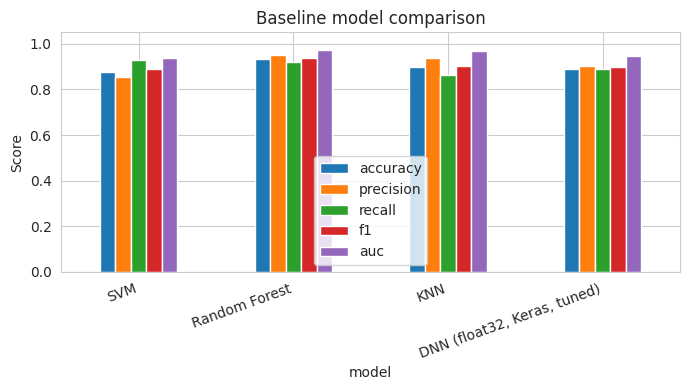

In [11]:

fig, ax = plt.subplots(figsize=(7, 4))
baseline_results_df[["accuracy", "precision", "recall", "f1", "auc"]].plot(kind="bar", ax=ax)
ax.set_title("Baseline model comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/baseline_comparison.png", dpi=150)
plt.show()


---
# 5. Compress the DNN — TFLite variants + ablation ladder (correction #11)

Variants produced:
- **float32** — TFLite conversion with no optimization (format-matched reference).
- **float16** — post-training float16 quantization.
- **int8** — post-training full-integer quantization, calibrated on a representative training sample.
- **finetune_only** *(new, #11)* — the float32 model fine-tuned for `PRUNING_EPOCHS` epochs with **no**
  pruning schedule applied (`target_sparsity=0`). Isolates how much of `pruned_int8`'s fidelity gain is
  just extra fine-tuning vs. actually being sparse.
- **pruned_f32** *(new, #11)* — magnitude-pruned + fine-tuned, converted to float32 TFLite **without**
  int8 quantization. Isolates pruning's effect from quantization's effect.
- **pruned_int8** — pruned_f32's model, additionally int8-quantized (the full compound variant).

Ablation reading order for the paper: `float32 -> finetune_only -> pruned_f32 -> int8-only -> pruned_int8`.


In [12]:

def representative_dataset_gen(X_train, n=200):
    def gen():
        for i in range(min(n, len(X_train))):
            yield [X_train[i:i + 1].astype(np.float32)]
    return gen


def convert_to_tflite(keras_model, variant, X_train_for_calib=None, out_path=None):
    """variant in {'float32','float16','int8'} -- pruning/fine-tuning happens to the KERAS model
    beforehand (see apply_pruning_and_finetune / finetune_only below); this function only handles the
    TFLite conversion/quantization step."""
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

    if variant == "float32":
        pass  # no optimization flags -> plain TFLite float32
    elif variant == "float16":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
    elif variant == "int8":
        assert X_train_for_calib is not None, "int8 quantization needs a representative dataset"
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_dataset_gen(X_train_for_calib)
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
    else:
        raise ValueError(f"unknown variant: {variant}")

    tflite_model = converter.convert()
    if out_path:
        with open(out_path, "wb") as f:
            f.write(tflite_model)
    return tflite_model


def gzip_size_kb(path):
    """correction #18: unstructured sparsity does not shrink a dense .tflite file on disk by itself
    (the zeros are still stored explicitly); gzip approximates what a real deployment pipeline would
    ship (compressed-at-rest, decompressed at load time on the MCU/edge gateway)."""
    gz_path = path + ".gz"
    with open(path, "rb") as f_in, gzip.open(gz_path, "wb", compresslevel=9) as f_out:
        shutil.copyfileobj(f_in, f_out)
    size_kb = os.path.getsize(gz_path) / 1024
    os.remove(gz_path)
    return size_kb


tflite_paths = {}
for variant in ["float32", "float16", "int8"]:
    path = f"{TFLITE_DIR}/dnn_{variant}.tflite"
    convert_to_tflite(dnn_model, variant, X_train_for_calib=X_tr2, out_path=path)
    tflite_paths[variant] = path
    size_kb = os.path.getsize(path) / 1024
    print(f"{variant:14s} -> {path}  ({size_kb:.1f} KB, gzip {gzip_size_kb(path):.1f} KB)")


float32        -> /content/outputs/tflite_models/dnn_float32.tflite  (40.8 KB, gzip 37.3 KB)
float16        -> /content/outputs/tflite_models/dnn_float16.tflite  (22.3 KB, gzip 19.5 KB)
int8           -> /content/outputs/tflite_models/dnn_int8.tflite  (17.2 KB, gzip 11.7 KB)


### 5.1 Pruning + fine-tuning helpers (ablation ladder, correction #11)

`apply_pruning_and_finetune(..., target_sparsity=0.0)` with `target_sparsity=0` gives the
**`finetune_only`** ablation for free (same fine-tuning loop, sparsity schedule ramps to 0), which is
exactly the isolation the supervisor asked for rather than a separately hand-written training loop that
could drift from the pruned path.


In [13]:
def clone_with_weights(keras_model):
    """Deep-copies a Keras model's architecture AND weights into a fresh, independent object.
    THE FIX: tfmot.sparsity.keras.prune_low_magnitude() wraps the SAME live layer objects
    (same underlying tf.Variables) rather than cloning them when given a full model -- so
    calling .fit() on the wrapped model silently mutates the ORIGINAL model's weights in
    place. Since apply_pruning_and_finetune() below is called twice on dnn_model (once for
    finetune_only, once for pruned_f32/pruned_int8), without this clone, dnn_model itself
    -- used everywhere downstream as "the float32 reference" -- ends up numerically close to
    the pruned+fine-tuned model by the time Section 8 computes reference SHAP values. This
    clone step is what stops that aliasing."""
    cloned = tf.keras.models.clone_model(keras_model)
    cloned.set_weights(keras_model.get_weights())
    return cloned


def apply_pruning_and_finetune(keras_model, X_tr, y_tr, X_val, y_val,
                                target_sparsity=PRUNING_TARGET_SPARSITY, epochs=PRUNING_EPOCHS):
    keras_model = clone_with_weights(keras_model)   # <-- THE FIX (one line)
    steps_per_epoch = int(np.ceil(len(X_tr) / 32))
    pruning_params = {
        "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.0, final_sparsity=target_sparsity,
            begin_step=0, end_step=steps_per_epoch * epochs,
        )
    }
    pruned_model = tfmot.sparsity.keras.prune_low_magnitude(keras_model, **pruning_params)
    pruned_model.compile(optimizer=keras.optimizers.Adam(1e-4),
                          loss="binary_crossentropy",
                          metrics=["accuracy", keras.metrics.AUC(name="auc")])
    pruned_model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
        verbose=0,
    )
    stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

    zero_fracs = [np.mean(np.abs(w) < 1e-8) for w in stripped_model.get_weights() if w.ndim == 2]
    achieved_sparsity = float(np.mean(zero_fracs)) if zero_fracs else 0.0
    return stripped_model, achieved_sparsity


# --- finetune_only (target_sparsity=0.0): isolates the fine-tuning effect (#11) -----------------
finetune_only_model, _ = apply_pruning_and_finetune(
    dnn_model, X_tr2, y_tr2, X_val, y_val, target_sparsity=0.0, epochs=PRUNING_EPOCHS)
finetune_only_path = f"{TFLITE_DIR}/dnn_finetune_only.tflite"
convert_to_tflite(finetune_only_model, "float32", out_path=finetune_only_path)
tflite_paths["finetune_only"] = finetune_only_path
print(f"finetune_only  -> {finetune_only_path}  ({os.path.getsize(finetune_only_path)/1024:.1f} KB)")

# --- pruned_f32 (headline sparsity, NOT quantized): isolates the pruning effect (#11) ------------
pruned_model, achieved_sparsity = apply_pruning_and_finetune(dnn_model, X_tr2, y_tr2, X_val, y_val,
                                                              target_sparsity=PRUNING_TARGET_SPARSITY,
                                                              epochs=PRUNING_EPOCHS)
print(f"Pruned model achieved sparsity in dense kernels: {achieved_sparsity*100:.1f}% "
      f"(target {PRUNING_TARGET_SPARSITY*100:.0f}%)")

pruned_f32_path = f"{TFLITE_DIR}/dnn_pruned_f32.tflite"
convert_to_tflite(pruned_model, "float32", out_path=pruned_f32_path)
tflite_paths["pruned_f32"] = pruned_f32_path
print(f"pruned_f32     -> {pruned_f32_path}  ({os.path.getsize(pruned_f32_path)/1024:.1f} KB, "
      f"gzip {gzip_size_kb(pruned_f32_path):.1f} KB)")

# --- pruned_int8 (headline sparsity, quantized): the full compound variant -----------------------
pruned_int8_path = f"{TFLITE_DIR}/dnn_pruned_int8.tflite"
convert_to_tflite(pruned_model, "int8", X_train_for_calib=X_tr2, out_path=pruned_int8_path)
tflite_paths["pruned_int8"] = pruned_int8_path
print(f"pruned_int8    -> {pruned_int8_path}  ({os.path.getsize(pruned_int8_path)/1024:.1f} KB, "
      f"gzip {gzip_size_kb(pruned_int8_path):.1f} KB)")

# --- sanity check: dnn_model must be UNCHANGED after both pruning branches above -----------------
_check_proba = dnn_model.predict(X_test, verbose=0).flatten()
_check_acc = accuracy_score(y_test, (_check_proba >= 0.5).astype(int))
print(f"\n[sanity check] dnn_model accuracy after pruning branches: {_check_acc:.4f} "
      f"-- this MUST match dnn_model's accuracy from Section 4.2, unchanged by anything above.")

finetune_only  -> /content/outputs/tflite_models/dnn_finetune_only.tflite  (40.8 KB)
Pruned model achieved sparsity in dense kernels: 49.6% (target 50%)
pruned_f32     -> /content/outputs/tflite_models/dnn_pruned_f32.tflite  (40.8 KB, gzip 23.8 KB)
pruned_int8    -> /content/outputs/tflite_models/dnn_pruned_int8.tflite  (17.2 KB, gzip 9.7 KB)

[sanity check] dnn_model accuracy after pruning branches: 0.8908 -- this MUST match dnn_model's accuracy from Section 4.2, unchanged by anything above.


In [15]:
from scipy.stats import spearmanr

def _self_test_load_interpreter(path):
    interp = tf.lite.Interpreter(model_path=path)
    interp.allocate_tensors()
    return interp

def _self_test_tflite_predict(interpreter, X):
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    in_scale, in_zero = input_details["quantization"]
    out_scale, out_zero = output_details["quantization"]
    X = np.asarray(X, dtype=np.float32)
    preds = np.empty(len(X), dtype=np.float32)
    for i in range(len(X)):
        row = X[i:i+1]
        if input_details["dtype"] in (np.int8, np.uint8):
            row_q = (row / in_scale + in_zero).round().astype(input_details["dtype"])
        else:
            row_q = row.astype(input_details["dtype"])
        interpreter.set_tensor(input_details["index"], row_q)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details["index"])
        if output_details["dtype"] in (np.int8, np.uint8):
            out = (out.astype(np.float32) - out_zero) * out_scale
        preds[i] = np.asarray(out, dtype=np.float64).reshape(-1)[0]
    return preds

def _self_test_topk_jaccard(v_ref, v_comp, k):
    top_ref = set(np.argsort(-np.abs(v_ref))[:k])
    top_comp = set(np.argsort(-np.abs(v_comp))[:k])
    union = top_ref | top_comp
    return len(top_ref & top_comp) / len(union) if union else 1.0

def _self_test_fidelity_metrics(ref_values, comp_values, k):
    n = ref_values.shape[0]
    jaccards, spearmans = [], []
    for i in range(n):
        jaccards.append(_self_test_topk_jaccard(ref_values[i], comp_values[i], k=k))
        rho, _ = spearmanr(ref_values[i], comp_values[i])
        spearmans.append(rho)
    return np.array(jaccards), np.array(spearmans)


# --- Supervisor-requested pipeline self-test: float32 Keras vs float32 TFLite should be ~1.000,
# computed through the SAME kind of exact-SHAP fidelity code path used for every other variant --
# not assumed. Fully self-contained; safe to run right after Section 5.1, before 5.2/8 exist. ---
_self_test_interp = _self_test_load_interpreter(tflite_paths["float32"])
_self_test_bg = shap.sample(X_tr2, SHAP_BACKGROUND_SIZE, random_state=RANDOM_STATE)
_self_test_masker = shap.maskers.Independent(_self_test_bg)

_ref_fn_test = lambda x: dnn_model.predict(x, verbose=0).flatten()
_var_fn_test = lambda x: _self_test_tflite_predict(_self_test_interp, x)

_self_test_subset = X_test[:30]  # small subset -- this is just a sanity check, not the real run

_ref_explainer_test = shap.Explainer(_ref_fn_test, _self_test_masker, feature_names=FEATURES, algorithm="exact")
_var_explainer_test = shap.Explainer(_var_fn_test, _self_test_masker, feature_names=FEATURES, algorithm="exact")

_ref_vals_test = _ref_explainer_test(_self_test_subset).values
_var_vals_test = _var_explainer_test(_self_test_subset).values

_jac_test, _spear_test = _self_test_fidelity_metrics(_ref_vals_test, _var_vals_test, k=TOP_K)
print(f"[PIPELINE SELF-TEST] float32 Keras vs float32 TFLite (same weights, same background):")
print(f"  top-{TOP_K} Jaccard = {np.nanmean(_jac_test):.4f}  (expected: essentially 1.0000)")
print(f"  Spearman rho        = {np.nanmean(_spear_test):.4f}  (expected: essentially 1.0000)")

ExactExplainer explainer: 31it [02:37,  5.23s/it]
ExactExplainer explainer: 31it [00:20,  1.26s/it]

[PIPELINE SELF-TEST] float32 Keras vs float32 TFLite (same weights, same background):
  top-5 Jaccard = 1.0000  (expected: essentially 1.0000)
  Spearman rho        = 1.0000  (expected: essentially 1.0000)


### 5.2 Batched / resized TFLite inference (correction #0)

The v3 notebook called the interpreter **once per sample**, in a Python loop — fine for a 60-sample
SHAP subset, painfully slow once SHAP runs over the full 238-sample test set with an exact explainer
(correction #12). `resize_tensor_input` lets one interpreter call handle up to `TFLITE_BATCH_SIZE` rows
at once. This also happens to be exactly what correction #0 asked for before anything else was touched.


In [16]:

def tflite_predict(interpreter, X, batch_size=TFLITE_BATCH_SIZE):
    """Batched TFLite inference (correction #0). Resizes the interpreter's input tensor to the batch
    size actually needed (capped at `batch_size`), handling int8-quantized I/O transparently. Falls
    back gracefully to batch=1 if the underlying model/interpreter doesn't support resizing (rare, but
    cheap to guard against)."""
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    in_scale, in_zero = input_details["quantization"]
    out_scale, out_zero = output_details["quantization"]

    X = np.asarray(X, dtype=np.float32)
    n = len(X)
    preds = np.empty(n, dtype=np.float32)
    cur_bs = None

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        xb = X[start:end]
        bs = xb.shape[0]
        if bs != cur_bs:
            try:
                interpreter.resize_tensor_input(input_details["index"], [bs, xb.shape[1]])
                interpreter.allocate_tensors()
                input_details = interpreter.get_input_details()[0]
                output_details = interpreter.get_output_details()[0]
                cur_bs = bs
            except (ValueError, RuntimeError):
                # some interpreters/models don't support batch resize -- fall back to per-row calls
                cur_bs = None

        if cur_bs is None:
            for i in range(bs):
                row = xb[i:i + 1]
                if input_details["dtype"] in (np.int8, np.uint8):
                    row_q = (row / in_scale + in_zero).round().astype(input_details["dtype"])
                else:
                    row_q = row.astype(input_details["dtype"])
                interpreter.set_tensor(input_details["index"], row_q)
                interpreter.invoke()
                out = interpreter.get_tensor(output_details["index"])
                if output_details["dtype"] in (np.int8, np.uint8):
                    out = (out.astype(np.float32) - out_zero) * out_scale
                preds[start + i] = np.asarray(out, dtype=np.float64).reshape(-1)[0]
            continue

        if input_details["dtype"] in (np.int8, np.uint8):
            xb_q = (xb / in_scale + in_zero).round().astype(input_details["dtype"])
        else:
            xb_q = xb.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], xb_q)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details["index"])
        if output_details["dtype"] in (np.int8, np.uint8):
            out = (out.astype(np.float32) - out_zero) * out_scale
        # correction #5: guard against NaN/Inf and shape surprises that caused the 233-vs-238
        # sample-count mismatch in v3's confusion matrices -- clip and flatten defensively.
        out_flat = np.nan_to_num(np.asarray(out, dtype=np.float64).reshape(bs, -1)[:, 0],
                                  nan=0.5, posinf=1.0, neginf=0.0)
        preds[start:end] = out_flat

    assert not np.isnan(preds).any(), "tflite_predict produced NaNs after nan_to_num -- investigate"
    assert len(preds) == n, f"tflite_predict returned {len(preds)} predictions for {n} inputs"
    return preds


def load_interpreter(path):
    interp = tf.lite.Interpreter(model_path=path)
    interp.allocate_tensors()
    return interp


interpreters = {v: load_interpreter(p) for v, p in tflite_paths.items()}

# Sanity check: accuracy of each TFLite variant should be close to the float32 Keras model, and every
# variant's confusion matrix must sum to exactly len(X_test) (correction #5's regression test).
for variant, interp in interpreters.items():
    proba = tflite_predict(interp, X_test)
    pred = (proba >= 0.5).astype(int)
    cm_sum = confusion_matrix(y_test, pred).sum()
    assert cm_sum == len(X_test), f"{variant}: confusion matrix sums to {cm_sum}, expected {len(X_test)}"
    row = evaluate_model(f"DNN ({variant}, TFLite)", y_test, pred, proba)
    results.append(row)

compressed_results_df = pd.DataFrame(results).set_index("model")
compressed_results_df.to_csv(f"{OUT_DIR}/all_model_comparison.csv")
compressed_results_df


,accuracy,precision,recall,f1,auc
model,,,,,
SVM,0.878151,0.854015,0.928571,0.889734,0.936473
Random Forest,0.932773,0.950820,0.920635,0.935484,0.972860
KNN,0.899160,0.939655,0.865079,0.900826,0.969069
"DNN (float32, Keras, tuned)",0.890756,0.903226,0.888889,0.896000,0.945437
"DNN (float32, TFLite)",0.890756,0.903226,0.888889,0.896000,0.945437
"DNN (float16, TFLite)",0.890756,0.903226,0.888889,0.896000,0.945649
"DNN (int8, TFLite)",0.899160,0.904762,0.904762,0.904762,0.945933
"DNN (finetune_only, TFLite)",0.894958,0.897638,0.904762,0.901186,0.946499
"DNN (pruned_f32, TFLite)",0.882353,0.895161,0.880952,0.888000,0.941893


### 5.3 Compression sweep — sparsity × int8 (correction #18)

If this sweep isn't included in the final paper for time reasons, the title's "not compression ratio"
framing should be softened to something like "...at matched footprint" rather than implying a sweep
that wasn't run. Running it is cheap (same fine-tune loop, different `target_sparsity`).


In [17]:

sweep_rows = []
for sparsity in SPARSITY_SWEEP:
    keras.backend.clear_session()
    m_sparse, achieved = apply_pruning_and_finetune(dnn_model, X_tr2, y_tr2, X_val, y_val,
                                                     target_sparsity=sparsity, epochs=PRUNING_EPOCHS)
    path = f"{TFLITE_DIR}/dnn_pruned_int8_sparsity{int(sparsity*100)}.tflite"
    convert_to_tflite(m_sparse, "int8", X_train_for_calib=X_tr2, out_path=path)

    interp = load_interpreter(path)
    proba = tflite_predict(interp, X_test)
    pred = (proba >= 0.5).astype(int)
    acc = accuracy_score(y_test, pred)
    size_kb = os.path.getsize(path) / 1024
    gz_kb = gzip_size_kb(path)

    sweep_rows.append({
        "target_sparsity": sparsity, "achieved_sparsity": achieved,
        "accuracy": acc, "size_kb": size_kb, "gzip_size_kb": gz_kb,
    })
    print(f"sparsity={sparsity:.1f} (achieved {achieved:.3f}) -> acc={acc:.3f}, "
          f"size={size_kb:.1f} KB, gzip={gz_kb:.1f} KB")

sparsity_sweep_df = pd.DataFrame(sweep_rows)
sparsity_sweep_df.to_csv(f"{OUT_DIR}/compression_sweep_sparsity.csv", index=False)
sparsity_sweep_df


sparsity=0.3 (achieved 0.296) -> acc=0.895, size=17.2 KB, gzip=11.0 KB
sparsity=0.5 (achieved 0.496) -> acc=0.882, size=17.2 KB, gzip=9.7 KB
sparsity=0.7 (achieved 0.690) -> acc=0.798, size=17.2 KB, gzip=7.9 KB
sparsity=0.9 (achieved 0.890) -> acc=0.555, size=17.2 KB, gzip=5.2 KB


,target_sparsity,achieved_sparsity,accuracy,size_kb,gzip_size_kb
0,0.3,0.296435,0.894958,17.25,10.950195
1,0.5,0.495835,0.882353,17.25,9.699219
2,0.7,0.689986,0.798319,17.25,7.866211
3,0.9,0.889582,0.554622,17.25,5.217773


---
# 6. Statistical significance of compression on predictions — McNemar's exact test (correction #8)

Eq. 14 in the paper was defined but never reported in Results in v3. This section now produces a table
covering **every** DNN variant (including the new ablation variants), which should be surfaced as either
a short paragraph or a small table column in the Results section — don't let this drop out again.


In [18]:

def mcnemar_exact(y_true, pred_a, pred_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    b = int(np.sum(correct_a & ~correct_b))   # a right, b wrong
    c = int(np.sum(~correct_a & correct_b))   # a wrong, b right
    n = b + c
    p_value = 1.0 if n == 0 else binomtest(min(b, c), n, 0.5).pvalue
    return {"b": b, "c": c, "n_discordant": n, "p_value": p_value}


float32_pred = (tflite_predict(interpreters["float32"], X_test) >= 0.5).astype(int)

ALL_VARIANTS_FOR_MCNEMAR = ["float16", "int8", "finetune_only", "pruned_f32", "pruned_int8"]

mcnemar_rows = []
for variant in ALL_VARIANTS_FOR_MCNEMAR:
    comp_pred = (tflite_predict(interpreters[variant], X_test) >= 0.5).astype(int)
    row = mcnemar_exact(y_test, float32_pred, comp_pred)
    row["variant"] = variant
    mcnemar_rows.append(row)

mcnemar_df = pd.DataFrame(mcnemar_rows).set_index("variant")[["b", "c", "n_discordant", "p_value"]]
mcnemar_df.to_csv(f"{OUT_DIR}/mcnemar_significance.csv")
print("McNemar's exact test vs. float32 reference (report this table or its p-values in Results):")
mcnemar_df


McNemar's exact test vs. float32 reference (report this table or its p-values in Results):


,b,c,n_discordant,p_value
variant,,,,
float16,0,0,0,1.000000
int8,0,2,2,0.500000
finetune_only,2,3,5,1.000000
pruned_f32,8,6,14,0.790527
pruned_int8,8,6,14,0.790527


---
# 7. Size and latency benchmarking (CPU proxy)

**Important for the paper:** these numbers are a *proxy*, not a real edge device. Use them to sanity-check
the pipeline; the numbers reported in the manuscript's results table should come from the Raspberry Pi /
ESP32 script in the final section of this notebook.


In [19]:

def benchmark_latency(predict_fn, X, n_runs=LATENCY_RUNS, warmup=10):
    sample = X[:1]
    for _ in range(warmup):
        predict_fn(sample)
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        predict_fn(sample)
        times.append((time.perf_counter() - t0) * 1000)  # ms
    return np.mean(times), np.std(times)


bench_rows = []

mean_ms, std_ms = benchmark_latency(lambda x: dnn_model.predict(x, verbose=0), X_test)
bench_rows.append({"model": DNN_LABEL, "latency_ms_mean": mean_ms, "latency_ms_std": std_ms, "size_kb": None})

for variant, interp in interpreters.items():
    fn = lambda x, interp=interp: tflite_predict(interp, x, batch_size=1)  # per-sample latency, not batched
    mean_ms, std_ms = benchmark_latency(fn, X_test)
    size_kb = os.path.getsize(tflite_paths[variant]) / 1024
    bench_rows.append({"model": f"DNN ({variant}, TFLite)", "latency_ms_mean": mean_ms,
                        "latency_ms_std": std_ms, "size_kb": size_kb})

bench_df = pd.DataFrame(bench_rows).set_index("model")
bench_df.to_csv(f"{OUT_DIR}/latency_size_benchmark_cpu_proxy.csv")
bench_df


,latency_ms_mean,latency_ms_std,size_kb
model,,,
"DNN (float32, Keras, tuned)",86.626381,20.209479,NaN
"DNN (float32, TFLite)",0.078965,0.011711,40.761719
"DNN (float16, TFLite)",0.080378,0.012907,22.285156
"DNN (int8, TFLite)",0.091022,0.009897,17.250000
"DNN (finetune_only, TFLite)",0.088067,0.023689,40.761719
"DNN (pruned_f32, TFLite)",0.084882,0.021543,40.761719
"DNN (pruned_int8, TFLite)",0.092698,0.013094,17.250000


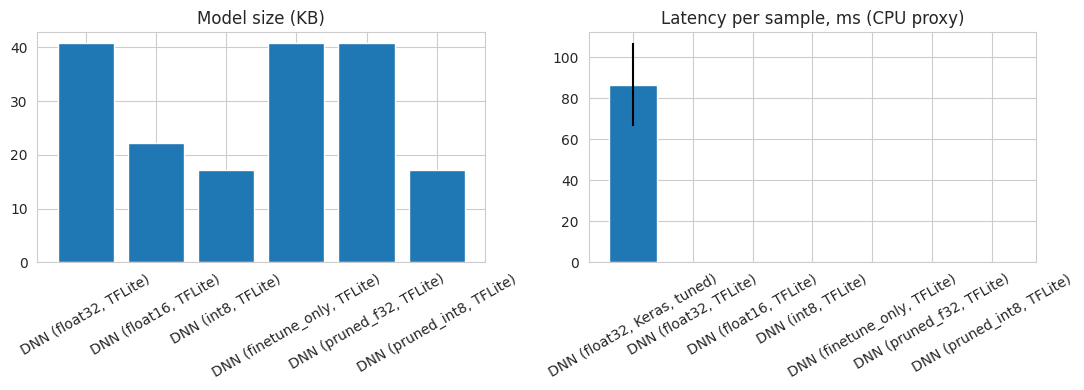

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_df = bench_df.dropna(subset=["size_kb"])
axes[0].bar(plot_df.index, plot_df["size_kb"])
axes[0].set_title("Model size (KB)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(bench_df.index, bench_df["latency_ms_mean"], yerr=bench_df["latency_ms_std"])
axes[1].set_title("Latency per sample, ms (CPU proxy)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/size_latency_cpu_proxy.png", dpi=150)
plt.show()


### 7.1 Confusion matrices and ROC curves — all models (correction #5)

Fixed to always include **all five DNN variants** in the row (float32 Keras, float32 TFLite, float16,
int8, pruned_int8), and the assertion in Section 5.2 now guarantees every confusion matrix here sums to
exactly `len(X_test)` — the 233-vs-238 bug can't silently reappear.


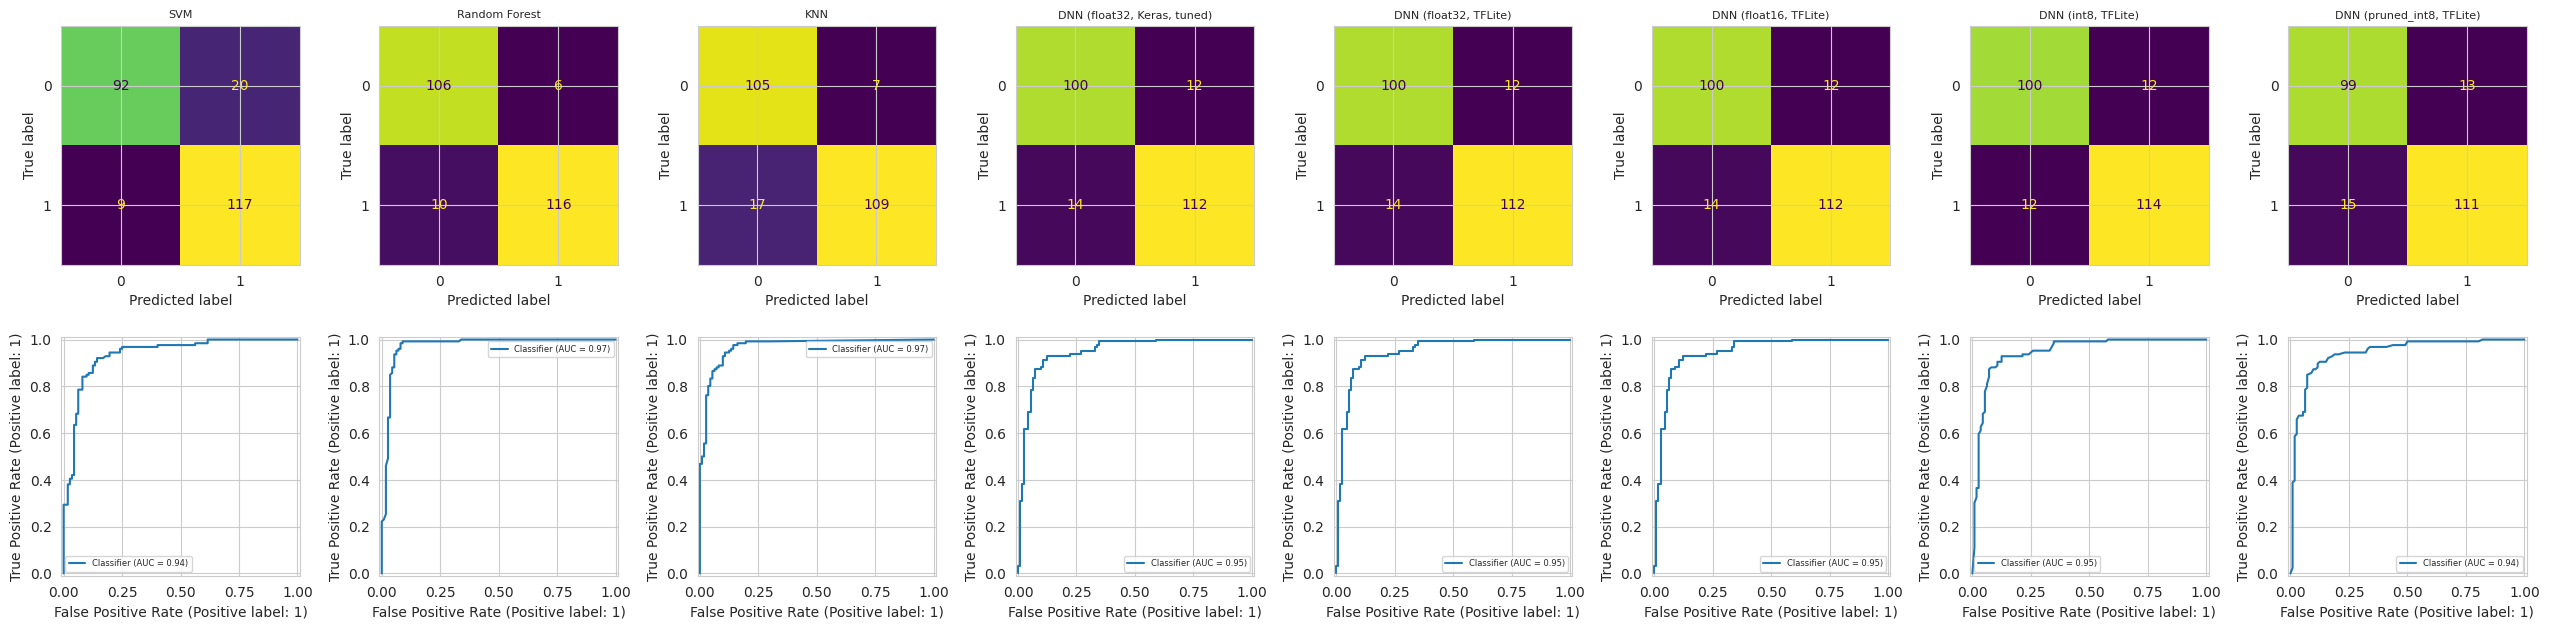


Confusion-matrix cell counts (verify against the paper's prose, e.g. float16's 99/13/15/111):
  SVM                              -> TN=92 FP=20 FN=9 TP=117
  Random Forest                    -> TN=106 FP=6 FN=10 TP=116
  KNN                              -> TN=105 FP=7 FN=17 TP=109
  DNN (float32, Keras, tuned)      -> TN=100 FP=12 FN=14 TP=112
  DNN (float32, TFLite)            -> TN=100 FP=12 FN=14 TP=112
  DNN (float16, TFLite)            -> TN=100 FP=12 FN=14 TP=112
  DNN (int8, TFLite)               -> TN=100 FP=12 FN=12 TP=114
  DNN (pruned_int8, TFLite)        -> TN=99 FP=13 FN=15 TP=111


In [21]:

model_preds = {
    "SVM": (svm_best.predict(X_test), svm_best.predict_proba(X_test)[:, 1]),
    "Random Forest": (rf_best.predict(X_test), rf_best.predict_proba(X_test)[:, 1]),
    "KNN": (knn_best.predict(X_test), knn_best.predict_proba(X_test)[:, 1]),
    DNN_LABEL: (y_pred_dnn, y_proba_dnn),
}
FIG3_DNN_VARIANTS = ["float32", "float16", "int8", "pruned_int8"]  # matches the paper's Table 1 rows exactly
for variant in FIG3_DNN_VARIANTS:
    proba = tflite_predict(interpreters[variant], X_test)
    pred = (proba >= 0.5).astype(int)
    cm_check = confusion_matrix(y_test, pred).sum()
    assert cm_check == len(X_test), f"Figure 3 regression: {variant} confusion matrix sums to {cm_check}"
    model_preds[f"DNN ({variant}, TFLite)"] = (pred, proba)

n_models = len(model_preds)
fig, axes = plt.subplots(2, n_models, figsize=(3.2 * n_models, 6.5))
for i, (name, (pred, proba)) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm).plot(ax=axes[0, i], colorbar=False)
    axes[0, i].set_title(name, fontsize=8)
    RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1, i])
    axes[1, i].set_title("")
    axes[1, i].legend(fontsize=6)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrices_and_roc.png", dpi=150)
plt.show()

print("\nConfusion-matrix cell counts (verify against the paper's prose, e.g. float16's 99/13/15/111):")
for name, (pred, proba) in model_preds.items():
    cm = confusion_matrix(y_test, pred)
    print(f"  {name:32s} -> TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")


---
# 8. Explanation-fidelity experiment — the paper's core contribution

**Correction #0 (do this first):** SHAP now uses the **exact** explainer (`algorithm="exact"`). With
`d=11` features there are only 2¹¹=2048 coalitions, so exact Shapley values are cheap and remove the
sampling noise of the default permutation approximation — this is why v3's numbers could move once this
is fixed (a headline of ρ≈0.92 becoming ρ≈~1.0 for float16, whose predictions never changed at all in
v3's own reported confusion matrices, would flip the paper's headline; whatever comes out, report it
honestly). The TFLite interpreter is also now called through the batched `tflite_predict` (correction #0
again), so running this over the full 238-sample test set (correction #12) is tractable.


In [22]:

def make_shap_predict_fn(kind, model_or_interp):
    if kind == "keras":
        return lambda x: model_or_interp.predict(x, verbose=0).flatten()
    else:
        return lambda x: tflite_predict(model_or_interp, x)


rng = np.random.default_rng(RANDOM_STATE)
if SHAP_TEST_SUBSET is None:
    X_shap_subset = X_test   # correction #12: full test set (238 samples), not a 60-sample subset
    print(f"Using the FULL test set for SHAP: {len(X_shap_subset)} samples.")
else:
    idx = rng.choice(len(X_test), size=min(SHAP_TEST_SUBSET, len(X_test)), replace=False)
    X_shap_subset = X_test[idx]
    print(f"Using a {len(X_shap_subset)}-sample SHAP subset (RUN_MODE='smoke').")

ALL_SHAP_VARIANTS = sorted(set(COMPRESSED_VARIANTS) | set(ABLATION_VARIANTS))
print("Variants explained against the float32 reference:", ALL_SHAP_VARIANTS)


Using the FULL test set for SHAP: 238 samples.
Variants explained against the float32 reference: ['finetune_only', 'float16', 'int8', 'pruned_f32', 'pruned_int8']


### 8.0 Noise floor — float32 vs. float32 (correction #0)

Two independent exact-SHAP runs on the **same** float32 Keras model, differing only in which background
sample is used to define the masking baseline. Any drift measured here is pure estimator/background
noise, not compression — it's the floor every compressed variant's fidelity score should be compared
against, and it must be computed and reported *before* interpreting the headline drift numbers.


In [23]:

background_a = shap.sample(X_tr2, SHAP_BACKGROUND_SIZE, random_state=RANDOM_STATE)
masker_a = shap.maskers.Independent(background_a)
background_b = shap.sample(X_tr2, SHAP_BACKGROUND_SIZE, random_state=RANDOM_STATE + 999)
masker_b = shap.maskers.Independent(background_b)

ref_fn = make_shap_predict_fn("keras", dnn_model)
explainer_a = shap.Explainer(ref_fn, masker_a, feature_names=FEATURES, algorithm="exact")
explainer_b = shap.Explainer(ref_fn, masker_b, feature_names=FEATURES, algorithm="exact")

print("Computing exact SHAP, float32 reference, background A ...")
shap_values_ref_a = explainer_a(X_shap_subset).values
print("Computing exact SHAP, float32 reference, background B (independent noise-floor run) ...")
shap_values_ref_b = explainer_b(X_shap_subset).values

# the rest of the notebook's "float32" reference is background A, used consistently everywhere downstream
shap_values = {"float32": shap_values_ref_a}
masker = masker_a


Computing exact SHAP, float32 reference, background A ...


ExactExplainer explainer: 239it [17:48,  4.51s/it]


Computing exact SHAP, float32 reference, background B (independent noise-floor run) ...


ExactExplainer explainer: 239it [17:37,  4.48s/it]


### 8.1 Fidelity metrics — top-$k$ Jaccard, Spearman $\rho$, and IWEF (correction #14/#15)

`IWEF` (Importance-Weighted Explanation Fidelity — renamed from `CWEF`, correction #14) now normalizes
each sample's weighted rank-displacement by that sample's own **maximum possible** weighted displacement
(a d×d maximum-weight assignment problem solved with `linear_sum_assignment`, correction #15), rather
than the uniform-weight bound `(d-1)`. This makes the metric provably tight in `[0,1]` regardless of how
skewed the weight vector is — the old bound could leave `F` unable to fall below ≈0.45 for a highly
skewed weight vector, understating drift.


In [24]:

def topk_jaccard(v_ref, v_comp, k=TOP_K):
    top_ref = set(np.argsort(-np.abs(v_ref))[:k])
    top_comp = set(np.argsort(-np.abs(v_comp))[:k])
    union = top_ref | top_comp
    return len(top_ref & top_comp) / len(union) if union else 1.0


def fidelity_metrics(ref_values, comp_values, k=TOP_K):
    n = ref_values.shape[0]
    jaccards, spearmans = [], []
    for i in range(n):
        jaccards.append(topk_jaccard(ref_values[i], comp_values[i], k=k))
        rho, _ = spearmanr(ref_values[i], comp_values[i])
        spearmans.append(rho)
    return np.array(jaccards), np.array(spearmans)


def compute_global_weights(ref_values, feature_names=FEATURES, override=CLINICAL_WEIGHT_OVERRIDE):
    """Global feature-importance weights w_j. Uses CLINICAL_WEIGHT_OVERRIDE if supplied (correction
    #14's hook for externally-sourced clinical weights); otherwise falls back to the data-derived
    mean |SHAP| weights from the float32 reference."""
    if override is not None:
        w = np.array([override.get(f, 0.0) for f in feature_names], dtype=float)
        if w.sum() <= 0:
            raise ValueError("CLINICAL_WEIGHT_OVERRIDE supplied but sums to 0 -- check feature names")
        return w / w.sum()
    mean_abs = np.abs(ref_values).mean(axis=0)
    total = mean_abs.sum()
    if total <= 0:
        return np.ones_like(mean_abs) / len(mean_abs)
    return mean_abs / total


def max_weighted_displacement(rank_ref, weights):
    """correction #15: the tight per-sample normalizer. Solves the d x d maximum-weight assignment
    problem -- feature j (holding reference rank rank_ref[j]) assigned to comparison rank r, cost
    w_j * |rank_ref[j] - r| -- via linear_sum_assignment(maximize=True). This is the largest weighted
    displacement any valid re-ranking of this sample's features could possibly produce."""
    d = len(rank_ref)
    ranks = np.arange(1, d + 1)
    C = np.abs(rank_ref[:, None] - ranks[None, :]) * weights[:, None]
    row_ind, col_ind = linear_sum_assignment(C, maximize=True)
    return C[row_ind, col_ind].sum()


def weighted_rank_displacement_tight(v_ref, v_comp, weights):
    rank_ref = pd.Series(-np.abs(v_ref)).rank(method="average").values
    rank_comp = pd.Series(-np.abs(v_comp)).rank(method="average").values
    raw_disp = float(np.sum(weights * np.abs(rank_ref - rank_comp)))
    d_max = max_weighted_displacement(rank_ref, weights)
    return raw_disp / d_max if d_max > 1e-12 else 0.0


def iwef_metrics(ref_values, comp_values, weights):
    """Per-sample Importance-Weighted Explanation Fidelity, F_i^v = 1 - D_i^v, tightly normalized."""
    n = ref_values.shape[0]
    iwef = np.zeros(n)
    for i in range(n):
        iwef[i] = 1.0 - weighted_rank_displacement_tight(ref_values[i], comp_values[i], weights)
    return iwef


# --- noise floor row, using the tight IWEF normalization -------------------------------------------
global_weights = compute_global_weights(shap_values["float32"])
jac_noise, spear_noise = fidelity_metrics(shap_values_ref_a, shap_values_ref_b, k=TOP_K)
iwef_noise = iwef_metrics(shap_values_ref_a, shap_values_ref_b, global_weights)

print("Global feature weights (sum = %.3f):" % global_weights.sum())
for feat, w in sorted(zip(FEATURES, global_weights), key=lambda t: -t[1]):
    print(f"  {feat:22s} {w:.4f}")

print("\nNoise floor (float32 vs float32, different SHAP background):")
print(f"  top-{TOP_K} Jaccard = {np.nanmean(jac_noise):.3f} +/- {np.nanstd(jac_noise):.3f}")
print(f"  Spearman rho        = {np.nanmean(spear_noise):.3f} +/- {np.nanstd(spear_noise):.3f}")
print(f"  IWEF                = {np.nanmean(iwef_noise):.3f} +/- {np.nanstd(iwef_noise):.3f}")


Global feature weights (sum = 1.000):
  st_slope               0.2118
  sex                    0.1411
  chest_pain_type        0.1203
  oldpeak                0.1090
  exercise_angina        0.1072
  fasting_blood_sugar    0.0674
  cholesterol            0.0603
  max_heart_rate         0.0595
  age                    0.0536
  resting_bp_s           0.0354
  resting_ecg            0.0344

Noise floor (float32 vs float32, different SHAP background):
  top-5 Jaccard = 0.781 +/- 0.177
  Spearman rho        = 0.939 +/- 0.049
  IWEF                = 0.829 +/- 0.062


### 8.2 SHAP for every compressed / ablation variant, against the float32 reference


In [25]:

per_sample_fidelity = {}
per_sample_iwef = {}
fidelity_rows = [{
    "variant": "float32_noise_floor",
    "topk_jaccard_mean": np.nanmean(jac_noise), "topk_jaccard_std": np.nanstd(jac_noise),
    "spearman_mean": np.nanmean(spear_noise), "spearman_std": np.nanstd(spear_noise),
    "iwef_mean": np.nanmean(iwef_noise), "iwef_std": np.nanstd(iwef_noise),
}]

for variant in ALL_SHAP_VARIANTS:
    print(f"Computing exact SHAP for variant='{variant}' ...")
    predict_fn = make_shap_predict_fn("tflite", interpreters[variant])
    explainer_v = shap.Explainer(predict_fn, masker, feature_names=FEATURES, algorithm="exact")
    shap_values[variant] = explainer_v(X_shap_subset).values

    jac, spear = fidelity_metrics(shap_values["float32"], shap_values[variant], k=TOP_K)
    iwef = iwef_metrics(shap_values["float32"], shap_values[variant], global_weights)
    per_sample_fidelity[variant] = {"jaccard": jac, "spearman": spear}
    per_sample_iwef[variant] = iwef

    fidelity_rows.append({
        "variant": variant,
        "topk_jaccard_mean": np.nanmean(jac), "topk_jaccard_std": np.nanstd(jac),
        "spearman_mean": np.nanmean(spear), "spearman_std": np.nanstd(spear),
        "iwef_mean": np.nanmean(iwef), "iwef_std": np.nanstd(iwef),
    })

fidelity_df = pd.DataFrame(fidelity_rows).set_index("variant")
fidelity_df.to_csv(f"{OUT_DIR}/explanation_fidelity_single_run.csv")
fidelity_df


Computing exact SHAP for variant='finetune_only' ...


ExactExplainer explainer: 239it [00:11,  3.20it/s]                         


Computing exact SHAP for variant='float16' ...


ExactExplainer explainer: 239it [00:11,  3.12it/s]                         


Computing exact SHAP for variant='int8' ...


...

Computing exact SHAP for variant='pruned_f32' ...


ExactExplainer explainer: 239it [00:11,  3.29it/s]


Computing exact SHAP for variant='pruned_int8' ...


ExactExplainer explainer: 239it [00:15,  5.29it/s]


,topk_jaccard_mean,topk_jaccard_std,spearman_mean,spearman_std,iwef_mean,iwef_std
variant,,,,,,
float32_noise_floor,0.780562,0.177344,0.939381,0.049298,0.828521,0.062371
finetune_only,0.939776,0.128249,0.984798,0.015212,0.944889,0.038026
float16,0.998599,0.021561,0.999885,0.001014,0.999646,0.003211
int8,0.970588,0.094546,0.995760,0.006270,0.978138,0.024715
pruned_f32,0.733193,0.200957,0.865241,0.090822,0.795039,0.080289
pruned_int8,0.733143,0.196186,0.864859,0.091392,0.795767,0.078305


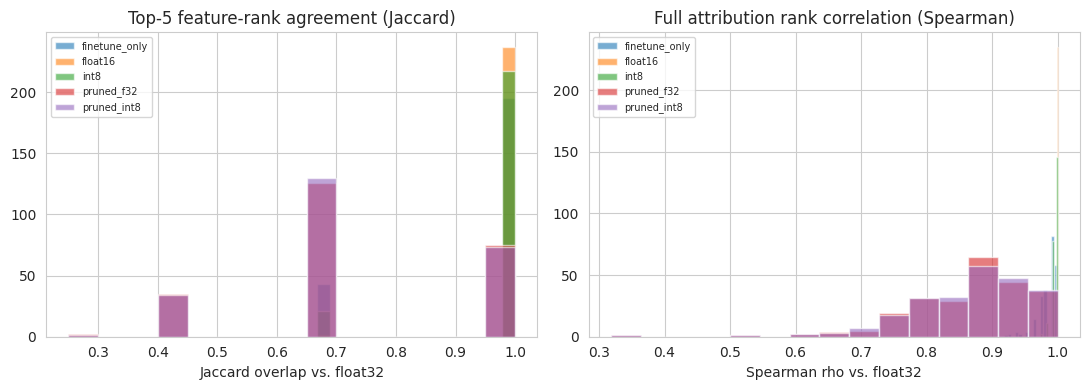

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
palette = sns.color_palette("tab10", n_colors=len(ALL_SHAP_VARIANTS))
for variant, color in zip(ALL_SHAP_VARIANTS, palette):
    axes[0].hist(per_sample_fidelity[variant]["jaccard"], bins=15, alpha=0.6, label=variant, color=color)
    axes[1].hist(per_sample_fidelity[variant]["spearman"], bins=15, alpha=0.6, label=variant, color=color)

axes[0].set_title(f"Top-{TOP_K} feature-rank agreement (Jaccard)")
axes[0].set_xlabel("Jaccard overlap vs. float32")
axes[0].legend(fontsize=7)

axes[1].set_title("Full attribution rank correlation (Spearman)")
axes[1].set_xlabel("Spearman rho vs. float32")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fidelity_distributions_single_run.png", dpi=150)
plt.show()


### 8.3 Clinical plausibility cross-check: DNN-SHAP vs. Random Forest feature importance


In [27]:

mean_abs_shap = np.abs(shap_values["float32"]).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=FEATURES)
rf_importance = pd.Series(rf_best.feature_importances_, index=FEATURES)

importance_compare = pd.DataFrame({
    "mean_abs_shap": shap_importance,
    "shap_rank": shap_importance.rank(ascending=False).astype(int),
    "rf_importance": rf_importance,
    "rf_rank": rf_importance.rank(ascending=False).astype(int),
}).sort_values("shap_rank")
importance_compare.to_csv(f"{OUT_DIR}/shap_vs_rf_feature_importance.csv")

rho, p = spearmanr(shap_importance.reindex(FEATURES), rf_importance.reindex(FEATURES))
print(f"Rank correlation, DNN-SHAP global importance vs. RF built-in importance: rho={rho:.3f} (p={p:.4f})")
importance_compare


Rank correlation, DNN-SHAP global importance vs. RF built-in importance: rho=0.418 (p=0.2006)


,mean_abs_shap,shap_rank,rf_importance,rf_rank
st_slope,0.134151,1,0.186121,1
sex,0.089334,2,0.045482,9
chest_pain_type,0.076217,3,0.136238,2
oldpeak,0.069034,4,0.118213,3
exercise_angina,0.067882,5,0.077647,8
fasting_blood_sugar,0.042708,6,0.022053,11
cholesterol,0.038188,7,0.090453,6
max_heart_rate,0.037660,8,0.117412,4
age,0.033970,9,0.096438,5
resting_bp_s,0.022443,10,0.084369,7


### 8.4 Second explainer — permutation importance (correction #20)

Integrated Gradients needs a differentiable model, and the TFLite interpreter is not differentiable, so
a second **model-agnostic** explainer is used instead: global permutation importance (accuracy drop when
a feature is shuffled). If SHAP-based and permutation-based rankings agree on which features drift under
compression, that's a much stronger claim than SHAP alone.


In [28]:

def permutation_feature_importance(predict_fn, X, y, n_repeats=10, seed=RANDOM_STATE):
    """Self-contained global permutation importance: mean accuracy drop when column j is shuffled,
    averaged over n_repeats shuffles. Model-agnostic -- works identically for the Keras model and
    every TFLite interpreter variant via the same predict_fn interface used throughout this notebook."""
    rng_local = np.random.default_rng(seed)
    baseline_pred = (predict_fn(X) >= 0.5).astype(int)
    baseline_acc = accuracy_score(y, baseline_pred)
    importances = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, j] = rng_local.permutation(X_perm[:, j])
            pred = (predict_fn(X_perm) >= 0.5).astype(int)
            drops.append(baseline_acc - accuracy_score(y, pred))
        importances[j] = np.mean(drops)
    return importances


perm_importance_ref = permutation_feature_importance(make_shap_predict_fn("keras", dnn_model), X_test, y_test)

perm_rows = []
perm_series = {"float32": pd.Series(perm_importance_ref, index=FEATURES)}
for variant in ALL_SHAP_VARIANTS:
    perm_v = permutation_feature_importance(make_shap_predict_fn("tflite", interpreters[variant]), X_test, y_test)
    perm_series[variant] = pd.Series(perm_v, index=FEATURES)

    rho_perm, _ = spearmanr(perm_importance_ref, perm_v)
    jac_perm = topk_jaccard(perm_importance_ref, perm_v, k=TOP_K)
    # cross-check: does the SECOND explainer agree with SHAP's fidelity ordering?
    shap_rho_this_variant = fidelity_df.loc[variant, "spearman_mean"] if variant in fidelity_df.index else np.nan
    perm_rows.append({
        "variant": variant, "perm_importance_rho_vs_float32": rho_perm,
        "perm_importance_topk_jaccard_vs_float32": jac_perm,
        "shap_spearman_mean_for_comparison": shap_rho_this_variant,
    })

perm_importance_df = pd.DataFrame(perm_rows).set_index("variant")
perm_importance_df.to_csv(f"{OUT_DIR}/second_explainer_permutation_importance.csv")
print("Second explainer (permutation importance) cross-check -- compare its rho column to SHAP's:")
perm_importance_df


Second explainer (permutation importance) cross-check -- compare its rho column to SHAP's:


,perm_importance_rho_vs_float32,perm_importance_topk_jaccard_vs_float32,shap_spearman_mean_for_comparison
variant,,,
finetune_only,0.970390,1.000000,0.984798
float16,1.000000,1.000000,0.999885
int8,0.990909,1.000000,0.995760
pruned_f32,0.890909,0.666667,0.865241
pruned_int8,0.872727,0.666667,0.864859


### 8.5 Theory result: a Shapley-linearity bound on rank swaps (correction #16)

**Proposition.** Exact Shapley values are a linear functional of the value function: for any coalition
$S$, $\phi_j(f) = \sum_S w_S\,[f(S\cup\{j\}) - f(S)]$ with weights $w_S \ge 0$ summing to 1 over the
subsets used. If two models $f_{\text{ref}}$ and $f_v$ satisfy $|f_v(x) - f_{\text{ref}}(x)| \le
\varepsilon$ for every coalition input $x$ the exact explainer evaluates, then every marginal
contribution changes by at most $2\varepsilon$, and since $\phi_j$ is a convex combination of marginal
contributions, $|\phi_j(f_v) - \phi_j(f_{\text{ref}})| \le 2\varepsilon$. Two features $j,k$ can only
swap rank if their reference attribution gap $|\phi_j(f_{\text{ref}}) - \phi_k(f_{\text{ref}})|$ is below
$4\varepsilon$ (worst case, both attributions move maximally in opposite directions). This is a
**guarantee**, not a fit — the cell below checks it holds empirically and reports how tight it is.

**Simplification used below:** $\varepsilon$ is estimated as the max absolute output difference between
$f_v$ and $f_{\text{ref}}$ over the test set and SHAP background combined, as a practical proxy for "every
coalition input the exact explainer evaluates" (which would require probing the exact masked inputs
directly). State this simplification explicitly if this result goes in the paper.


In [29]:

def estimate_epsilon(ref_fn, var_fn, X_probe):
    return float(np.max(np.abs(ref_fn(X_probe) - var_fn(X_probe))))


def theory_bound_check(phi_ref, phi_var, epsilon):
    m, d = phi_ref.shape
    threshold = 4 * epsilon
    total_pairs = flips = flips_within_bound = at_risk = 0
    for i in range(m):
        for j in range(d):
            for k in range(j + 1, d):
                total_pairs += 1
                gap = abs(phi_ref[i, j] - phi_ref[i, k])
                sign_ref = np.sign(phi_ref[i, j] - phi_ref[i, k])
                sign_var = np.sign(phi_var[i, j] - phi_var[i, k])
                flipped = (sign_ref != sign_var) and sign_ref != 0 and sign_var != 0
                risky = gap < threshold
                if flipped:
                    flips += 1
                    if risky:
                        flips_within_bound += 1
                if risky:
                    at_risk += 1
    return {
        "epsilon": epsilon, "threshold_4eps": threshold, "total_pairs": total_pairs,
        "observed_flips": flips, "flips_violating_bound": flips - flips_within_bound,
        "predicted_at_risk_pairs": at_risk,
        "bound_tightness_precision": flips_within_bound / at_risk if at_risk else np.nan,
        "bound_recall_should_be_1": flips_within_bound / flips if flips else np.nan,
    }


X_probe = np.concatenate([X_shap_subset, background_a, background_b], axis=0)
ref_fn_probe = make_shap_predict_fn("keras", dnn_model)

theory_rows = []
for variant in ALL_SHAP_VARIANTS:
    var_fn_probe = make_shap_predict_fn("tflite", interpreters[variant])
    eps_v = estimate_epsilon(ref_fn_probe, var_fn_probe, X_probe)
    row = theory_bound_check(shap_values["float32"], shap_values[variant], eps_v)
    row["variant"] = variant
    theory_rows.append(row)

theory_bound_df = pd.DataFrame(theory_rows).set_index("variant")
theory_bound_df.to_csv(f"{OUT_DIR}/theory_bound_check.csv")
print("If 'flips_violating_bound' is not ~0 for any variant, the epsilon proxy is too loose -- tighten it")
print("(e.g. probe the actual masked coalition inputs) before citing this as a guarantee in the paper.")
theory_bound_df


If 'flips_violating_bound' is not ~0 for any variant, the epsilon proxy is too loose -- tighten it
(e.g. probe the actual masked coalition inputs) before citing this as a guarantee in the paper.


,epsilon,threshold_4eps,total_pairs,observed_flips,flips_violating_bound,predicted_at_risk_pairs,bound_tightness_precision,bound_recall_should_be_1
variant,,,,,,,,
finetune_only,0.172581,0.690325,13090,328,0,13090,0.025057,1.0
float16,0.000715,0.002862,13090,3,0,315,0.009524,1.0
int8,0.041466,0.165864,13090,108,0,11723,0.009213,1.0
pruned_f32,0.858197,3.432788,13090,1676,0,13090,0.128037,1.0
pruned_int8,0.868222,3.472889,13090,1678,0,13090,0.128189,1.0


---
# 9. Multi-seed fidelity variance (correction #12)

Repeats the **entire** pipeline (impute -> split -> train DNN -> compress into every ablation variant ->
exact SHAP over the full test set -> fidelity metrics) across `N_SEEDS` seeds (`SEED_LIST`, default 10,
was 3). Imputation and standardization are refit on **each seed's own training partition only** (no
leakage), which is the version of Section 2 that should be described in the paper. This is by far the
slowest cell in the notebook — use `RUN_MODE="smoke"` first.


In [30]:

def prepare_seed_split(df_raw_with_nans, target, features, num_cols, seed, test_size=0.2, val_size=0.15):
    """Leakage-safe per-seed imputation + standardization + split, reused by every seed and by the
    dedup-sensitivity run (correction #10) so both share exactly the same procedure."""
    y_all = df_raw_with_nans[target].values.astype(np.int32)
    idx_all = np.arange(len(df_raw_with_nans))
    train_idx, test_idx = train_test_split(idx_all, test_size=test_size, stratify=y_all, random_state=seed)

    df_local = df_raw_with_nans.copy()
    for col in num_cols:
        if df_local[col].isna().any():
            med = df_local.loc[train_idx, col].median()
            df_local[col] = df_local[col].fillna(med)

    df_std_local, _ = zscore_standardize_train_only(df_local.iloc[train_idx], df_local, num_cols)

    X_all = df_std_local[features].values.astype(np.float32)
    X_tr, X_te = X_all[train_idx], X_all[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]
    X_tr2_s, X_val_s, y_tr2_s, y_val_s = train_test_split(X_tr, y_tr, test_size=val_size,
                                                            stratify=y_tr, random_state=seed)
    return X_tr2_s, X_val_s, X_te, y_tr2_s, y_val_s, y_te


def run_full_pipeline_for_seed(seed, df_raw_with_nans, target, features, num_cols,
                                best_cfg=None, shap_subset_size=SHAP_TEST_SUBSET,
                                variants=ALL_SHAP_VARIANTS, verbose_tag=""):
    best_cfg = best_cfg or best_config
    X_tr2_s, X_val_s, X_te, y_tr2_s, y_val_s, y_te = prepare_seed_split(
        df_raw_with_nans, target, features, num_cols, seed)

    cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_tr2_s), y=y_tr2_s)
    cw_dict = {int(c): w for c, w in zip(np.unique(y_tr2_s), cw)}

    keras.backend.clear_session()
    tf.random.set_seed(seed)
    model = build_dnn(X_tr2_s.shape[1], **best_cfg)
    model = train_dnn(model, X_tr2_s, y_tr2_s, X_val_s, y_val_s, class_weight=cw_dict,
                       epochs=150, patience=15, seed=seed, verbose=0)

    variant_paths = {}
    if "float16" in variants:
        p = f"{TFLITE_DIR}/dnn_float16_seed{seed}{verbose_tag}.tflite"
        convert_to_tflite(model, "float16", out_path=p); variant_paths["float16"] = p
    if "int8" in variants:
        p = f"{TFLITE_DIR}/dnn_int8_seed{seed}{verbose_tag}.tflite"
        convert_to_tflite(model, "int8", X_train_for_calib=X_tr2_s, out_path=p); variant_paths["int8"] = p
    if "finetune_only" in variants:
        ft_model, _ = apply_pruning_and_finetune(model, X_tr2_s, y_tr2_s, X_val_s, y_val_s,
                                                  target_sparsity=0.0, epochs=PRUNING_EPOCHS)
        p = f"{TFLITE_DIR}/dnn_finetune_only_seed{seed}{verbose_tag}.tflite"
        convert_to_tflite(ft_model, "float32", out_path=p); variant_paths["finetune_only"] = p
    if "pruned_f32" in variants or "pruned_int8" in variants:
        pruned_model_s, _ = apply_pruning_and_finetune(model, X_tr2_s, y_tr2_s, X_val_s, y_val_s,
                                                        target_sparsity=PRUNING_TARGET_SPARSITY,
                                                        epochs=PRUNING_EPOCHS)
        if "pruned_f32" in variants:
            p = f"{TFLITE_DIR}/dnn_pruned_f32_seed{seed}{verbose_tag}.tflite"
            convert_to_tflite(pruned_model_s, "float32", out_path=p); variant_paths["pruned_f32"] = p
        if "pruned_int8" in variants:
            p = f"{TFLITE_DIR}/dnn_pruned_int8_seed{seed}{verbose_tag}.tflite"
            convert_to_tflite(pruned_model_s, "int8", X_train_for_calib=X_tr2_s, out_path=p)
            variant_paths["pruned_int8"] = p

    if shap_subset_size is None:
        X_sub = X_te
    else:
        rng_local = np.random.default_rng(seed)
        idx = rng_local.choice(len(X_te), size=min(shap_subset_size, len(X_te)), replace=False)
        X_sub = X_te[idx]

    bg = shap.sample(X_tr2_s, SHAP_BACKGROUND_SIZE, random_state=seed)
    local_masker = shap.maskers.Independent(bg)

    ref_fn = make_shap_predict_fn("keras", model)
    ref_explainer = shap.Explainer(ref_fn, local_masker, feature_names=features, algorithm="exact")
    ref_values = ref_explainer(X_sub).values
    local_weights = compute_global_weights(ref_values, feature_names=features)

    # correction #7: float32's OWN accuracy is also reported multi-seed (a small MLP is cheap to
    # retrain per seed), not just the compressed variants -- fidelity vs. itself is trivially 1.0.
    ref_proba_full = ref_fn(X_te)
    ref_pred_full = (ref_proba_full >= 0.5).astype(int)
    seed_rows = [{
        "seed": seed, "variant": "float32", "accuracy": accuracy_score(y_te, ref_pred_full),
        "topk_jaccard_mean": 1.0, "spearman_mean": 1.0, "iwef_mean": 1.0,
        "_jaccard_persample": np.ones(len(X_sub)), "_spearman_persample": np.ones(len(X_sub)),
        "_iwef_persample": np.ones(len(X_sub)),
    }]
    for variant in variants:
        interp = load_interpreter(variant_paths[variant])
        comp_fn = make_shap_predict_fn("tflite", interp)
        comp_explainer = shap.Explainer(comp_fn, local_masker, feature_names=features, algorithm="exact")
        comp_values = comp_explainer(X_sub).values

        jac, spear = fidelity_metrics(ref_values, comp_values, k=TOP_K)
        iwef = iwef_metrics(ref_values, comp_values, local_weights)

        proba = tflite_predict(interp, X_te)
        pred = (proba >= 0.5).astype(int)
        acc = accuracy_score(y_te, pred)

        seed_rows.append({
            "seed": seed, "variant": variant, "accuracy": acc,
            "topk_jaccard_mean": np.nanmean(jac), "spearman_mean": np.nanmean(spear),
            "iwef_mean": np.nanmean(iwef),
            # kept per-sample for the paired Wilcoxon test in Section 11 (correction #13)
            "_jaccard_persample": jac, "_spearman_persample": spear, "_iwef_persample": iwef,
        })
    return seed_rows


df_seed_source, _, _, _ = preprocess_dataset(ACTIVE_DATASET_KEY)   # has NaNs where zero-as-missing, unfilled

all_seed_rows = []
for seed in SEED_LIST:
    print(f"--- seed {seed} ({SEED_LIST.index(seed)+1}/{len(SEED_LIST)}) ---")
    all_seed_rows.extend(run_full_pipeline_for_seed(seed, df_seed_source, TARGET, FEATURES, NUM_COLS))

seed_variance_df = pd.DataFrame(all_seed_rows)
seed_variance_df.drop(columns=[c for c in seed_variance_df.columns if c.startswith("_")]) \
    .to_csv(f"{OUT_DIR}/fidelity_variance_across_seeds.csv", index=False)
seed_variance_df.drop(columns=[c for c in seed_variance_df.columns if c.startswith("_")])


[D1] disguised missing values: cholesterol==0 in 172/1190 rows (14.5%) -- imputed with training-median downstream.
[D1] disguised missing values: resting_bp_s==0 in 1/1190 rows (0.1%) -- imputed with training-median downstream.
--- seed 42 (1/10) ---


ExactExplainer explainer: 239it [19:43,  5.00s/it]
ExactExplainer explainer: 239it [00:12,  4.33it/s]                         
ExactExplainer explainer: 239it [00:12,  3.89it/s]
ExactExplainer explainer: 239it [00:15,  5.86it/s]                         
ExactExplainer explainer: 239it [00:11,  3.60it/s]                         
ExactExplainer explainer: 239it [00:16,  5.69it/s]                         


--- seed 43 (2/10) ---


ExactExplainer explainer: 239it [19:12,  4.88s/it]
ExactExplainer explainer: 239it [00:12,  4.05it/s]
ExactExplainer explainer: 239it [00:12,  4.09it/s]
ExactExplainer explainer: 239it [00:16,  5.66it/s]
ExactExplainer explainer: 239it [00:11,  2.55it/s]
ExactExplainer explainer: 239it [00:16,  5.43it/s]


--- seed 44 (3/10) ---


...

--- seed 50 (9/10) ---


ExactExplainer explainer: 239it [20:17,  5.14s/it]
ExactExplainer explainer: 239it [00:11,  3.55it/s]                         
ExactExplainer explainer: 239it [00:11,  3.47it/s]
ExactExplainer explainer: 239it [00:15,  5.70it/s]
ExactExplainer explainer: 239it [00:12,  4.34it/s]                         
ExactExplainer explainer: 239it [00:15,  5.71it/s]


--- seed 51 (10/10) ---


ExactExplainer explainer: 239it [20:44,  5.27s/it]
ExactExplainer explainer: 239it [00:12,  3.81it/s]
ExactExplainer explainer: 239it [00:12,  3.11it/s]                         
ExactExplainer explainer: 239it [00:15,  5.32it/s]                         
ExactExplainer explainer: 239it [00:12,  3.85it/s]                         
ExactExplainer explainer: 239it [00:15,  5.89it/s]


,seed,variant,accuracy,topk_jaccard_mean,spearman_mean,iwef_mean
0,42,float32,0.890756,1.000000,1.000000,1.000000
1,42,finetune_only,0.894958,0.913165,0.976662,0.932855
2,42,float16,0.890756,0.998599,1.000000,0.999749
3,42,int8,0.890756,0.974790,0.995531,0.978063
4,42,pruned_f32,0.827731,0.701130,0.849083,0.804961
5,42,pruned_int8,0.831933,0.701931,0.850153,0.804830
6,43,float32,0.865546,1.000000,1.000000,1.000000
7,43,finetune_only,0.882353,0.877551,0.975057,0.921739
8,43,float16,0.865546,1.000000,1.000000,0.999955
9,43,int8,0.869748,0.987395,0.996944,0.989761


In [31]:

def ci95_t(s):
    """Student-t 95% CI half-width (matches the paper's Eq. 13), correct for any S (was hardcoded
    for S=3 in spirit; here it generalizes automatically as N_SEEDS grows)."""
    s = pd.Series(s).dropna()
    n = len(s)
    if n <= 1:
        return np.nan
    return student_t.ppf(0.975, n - 1) * s.std(ddof=1) / np.sqrt(n)


summary_cols = ["accuracy", "topk_jaccard_mean", "spearman_mean", "iwef_mean"]
summary = seed_variance_df.groupby("variant")[summary_cols].agg(["mean", "std", ci95_t])
summary.to_csv(f"{OUT_DIR}/fidelity_variance_summary.csv")
summary


accuracy                     topk_jaccard_mean            \
                   mean       std    ci95_t              mean       std   
variant                                                                   
finetune_only  0.871429  0.021715  0.015534          0.890766  0.042537   
float16        0.871008  0.020873  0.014931          0.999440  0.000723   
float32        0.871008  0.020873  0.014931          1.000000  0.000000   
int8           0.868908  0.021406  0.015313          0.971854  0.014907   
pruned_f32     0.830672  0.013441  0.009615          0.705557  0.040071   
pruned_int8    0.827731  0.014555  0.010412          0.701160  0.042622   

                        spearman_mean                     iwef_mean            \
                 ci95_t          mean       std    ci95_t      mean       std   
variant                                                                         
finetune_only  0.030429      0.973220  0.013012  0.009308  0.920752  0.034228   
float16        0.000517      0.999931  0.000080  0.000057  0.999623  0.000296   
float32        0.000000      1.000000  0.000000  0.000000  1.000000  0.000000   
int8           0.010664      0.992422  0.005296  0.003789  0.977778  0.010051   
pruned_f32     0.028665      0.886929  0.028644  0.020490  0.802193  0.029859   
pruned_int8    0.030490      0.885535  0.026720  0.019114  0.800175  0.031454   

                         
                 ci95_t  
variant                  
finetune_only  0.024485  
float16        0.000212  
float32        0.000000  
int8           0.007190  
pruned_f32     0.021360  
pruned_int8    0.022501

---
# 10. Dedup sensitivity analysis (correction #10)

D1 has `n_dupes` exact duplicate rows (Section 1) — a real limitation of the dataset (already listed
in the paper's Conclusion). This section re-runs the identical multi-seed protocol on the de-duplicated
copy and checks whether the **fidelity ordering** (which variant preserves explanations best) survives,
not just whether point estimates shift a little. `DEDUP_N_SEEDS` defaults smaller than `N_SEEDS` purely
for runtime — raise it to `N_SEEDS` if you have the compute budget for the final numbers.


In [32]:

df_dedup_source, target_dedup, features_dedup, num_cols_dedup = preprocess_dataset("D1_dedup")
assert features_dedup == FEATURES, "feature set changed after dedup -- investigate before comparing"

dedup_seed_list = SEED_LIST[:DEDUP_N_SEEDS]
dedup_seed_rows = []
for seed in dedup_seed_list:
    print(f"--- [dedup] seed {seed} ({dedup_seed_list.index(seed)+1}/{len(dedup_seed_list)}) ---")
    dedup_seed_rows.extend(run_full_pipeline_for_seed(
        seed, df_dedup_source, target_dedup, features_dedup, num_cols_dedup, verbose_tag="_dedup"))

dedup_variance_df = pd.DataFrame(dedup_seed_rows)
dedup_summary = dedup_variance_df.groupby("variant")[summary_cols].agg(["mean", "std", ci95_t])
dedup_variance_df.drop(columns=[c for c in dedup_variance_df.columns if c.startswith("_")]) \
    .to_csv(f"{OUT_DIR}/dedup_sensitivity_seeds.csv", index=False)
dedup_summary.to_csv(f"{OUT_DIR}/dedup_sensitivity_summary.csv")

# --- ordering comparison: does the ranking of variants by mean IWEF/Spearman survive dedup? --------
orig_order = summary[("iwef_mean", "mean")].loc[dedup_summary.index].rank(ascending=False)
dedup_order = dedup_summary[("iwef_mean", "mean")].rank(ascending=False)
order_rho, order_p = spearmanr(orig_order, dedup_order)

print(f"\nOriginal D1 (n={len(df_heart_disease)}) vs. de-duplicated D1 (n={len(df_heart_disease_dedup)}):")
print(f"Rank correlation of variant ordering by mean IWEF (original vs. dedup): rho={order_rho:.3f} (p={order_p:.4f})")
print("rho close to 1.0 means the paper's ranking of variants by fidelity is NOT an artifact of the")
print("duplicate rows -- report this number (or the comparison table below) as the dedup-robustness check.")

pd.concat({"original": summary.loc[dedup_summary.index, ("iwef_mean", "mean")],
           "dedup": dedup_summary[("iwef_mean", "mean")]}, axis=1)


[D1_dedup] disguised missing values: cholesterol==0 in 172/918 rows (18.7%) -- imputed with training-median downstream.
[D1_dedup] disguised missing values: resting_bp_s==0 in 1/918 rows (0.1%) -- imputed with training-median downstream.
--- [dedup] seed 42 (1/5) ---


ExactExplainer explainer: 185it [15:22,  5.04s/it]
ExactExplainer explainer: 185it [00:11,  1.35it/s]                         
ExactExplainer explainer: 185it [00:11,  2.78it/s]                         


--- [dedup] seed 43 (2/5) ---


ExactExplainer explainer: 185it [15:27,  5.09s/it]
ExactExplainer explainer: 185it [00:11,  1.61it/s]                         
ExactExplainer explainer: 185it [00:11,  2.76it/s]                         


--- [dedup] seed 44 (3/5) ---


...

ExactExplainer explainer: 185it [15:29,  5.08s/it]
ExactExplainer explainer: 185it [00:11,  2.39it/s]                         
ExactExplainer explainer: 185it [00:11,  2.27it/s]


--- [dedup] seed 46 (5/5) ---


ExactExplainer explainer: 185it [15:32,  5.09s/it]
ExactExplainer explainer: 185it [00:11,  2.10it/s]
ExactExplainer explainer: 185it [00:12,  2.61it/s]                         



Original D1 (n=1190) vs. de-duplicated D1 (n=918):
Rank correlation of variant ordering by mean IWEF (original vs. dedup): rho=1.000 (p=0.0000)
rho close to 1.0 means the paper's ranking of variants by fidelity is NOT an artifact of the
duplicate rows -- report this number (or the comparison table below) as the dedup-robustness check.


,original,dedup
variant,,
finetune_only,0.920752,0.925783
float16,0.999623,0.999753
float32,1.000000,1.000000
int8,0.977778,0.983194
pruned_f32,0.802193,0.819704
pruned_int8,0.800175,0.819137


---
# 11. The 3-way trade-off plot: accuracy vs. size vs. explanation fidelity (correction #6)

Built from the **exact same** `tradeoff_df` that feeds Table 1 (no separate/stale run), with 95% CI
error bars from the multi-seed summary, and `pruned_f32` plotted explicitly as a **labeled ablation**
point (open marker) rather than either mysteriously appearing or being silently dropped.


In [33]:

tradeoff_rows = []
tradeoff_rows.append({
    # correction #7: float32 accuracy is now the multi-seed mean too (Section 9), not the single
    # primary-split number -- consistent with every other DNN row in this table.
    "variant": "float32", "is_ablation": False,
    "accuracy": summary.loc["float32", ("accuracy", "mean")],
    "size_kb": os.path.getsize(tflite_paths["float32"]) / 1024,
    "topk_jaccard_mean": 1.0, "spearman_mean": 1.0, "iwef_mean": 1.0,
    "accuracy_ci": summary.loc["float32", ("accuracy", "ci95_t")], "spearman_ci": 0.0, "iwef_ci": 0.0,
})
for variant in ALL_SHAP_VARIANTS:
    is_abl = variant in ("finetune_only", "pruned_f32")
    tradeoff_rows.append({
        "variant": variant, "is_ablation": is_abl,
        "accuracy": summary.loc[variant, ("accuracy", "mean")],
        "size_kb": os.path.getsize(tflite_paths[variant]) / 1024,
        "topk_jaccard_mean": summary.loc[variant, ("topk_jaccard_mean", "mean")],
        "spearman_mean": summary.loc[variant, ("spearman_mean", "mean")],
        "iwef_mean": summary.loc[variant, ("iwef_mean", "mean")],
        "accuracy_ci": summary.loc[variant, ("accuracy", "ci95_t")],
        "spearman_ci": summary.loc[variant, ("spearman_mean", "ci95_t")],
        "iwef_ci": summary.loc[variant, ("iwef_mean", "ci95_t")],
    })

tradeoff_df = pd.DataFrame(tradeoff_rows).set_index("variant")
tradeoff_df.to_csv(f"{OUT_DIR}/tradeoff_table.csv")
tradeoff_df


,is_ablation,accuracy,size_kb,topk_jaccard_mean,spearman_mean,iwef_mean,accuracy_ci,spearman_ci,iwef_ci
variant,,,,,,,,,
float32,False,0.871008,40.761719,1.000000,1.000000,1.000000,0.014931,0.000000,0.000000
finetune_only,True,0.871429,40.761719,0.890766,0.973220,0.920752,0.015534,0.009308,0.024485
float16,False,0.871008,22.285156,0.999440,0.999931,0.999623,0.014931,0.000057,0.000212
int8,False,0.868908,17.250000,0.971854,0.992422,0.977778,0.015313,0.003789,0.007190
pruned_f32,True,0.830672,40.761719,0.705557,0.886929,0.802193,0.009615,0.020490,0.021360
pruned_int8,False,0.827731,17.250000,0.701160,0.885535,0.800175,0.010412,0.019114,0.022501


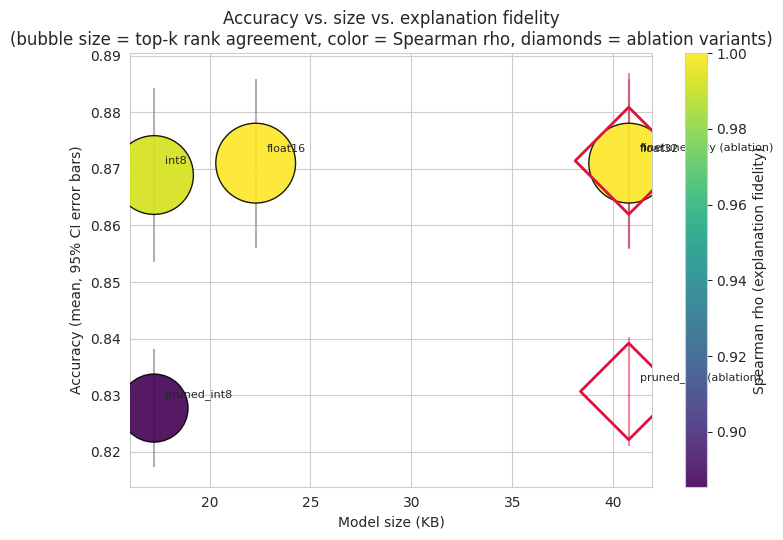

Sanity check -- these sizes MUST match Table 1 exactly (correction #6):
variant
float32          40.76
finetune_only    40.76
float16          22.29
int8             17.25
pruned_f32       40.76
pruned_int8      17.25
Name: size_kb, dtype: float64


In [34]:

plot_df = tradeoff_df.copy()
headline_df = plot_df[~plot_df["is_ablation"]]
ablation_df = plot_df[plot_df["is_ablation"]]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

sizes_h = 300 + 3000 * headline_df["topk_jaccard_mean"].fillna(0.5)
sc = ax.scatter(headline_df["size_kb"], headline_df["accuracy"], s=sizes_h,
                 c=headline_df["spearman_mean"], cmap="viridis", edgecolor="k", alpha=0.9,
                 marker="o", label=None, zorder=3)
ax.errorbar(headline_df["size_kb"], headline_df["accuracy"],
            yerr=headline_df["accuracy_ci"], fmt="none", ecolor="gray", alpha=0.6, zorder=2)

# ablation points: same color scale, but open/hollow markers so they read as "ablation" at a glance
sizes_a = 300 + 3000 * ablation_df["topk_jaccard_mean"].fillna(0.5)
ax.scatter(ablation_df["size_kb"], ablation_df["accuracy"], s=sizes_a,
           facecolors="none", edgecolors="crimson", linewidths=2, marker="D", zorder=3)
ax.errorbar(ablation_df["size_kb"], ablation_df["accuracy"],
            yerr=ablation_df["accuracy_ci"], fmt="none", ecolor="crimson", alpha=0.5, zorder=2)

for variant, row in plot_df.iterrows():
    label = f"{variant} (ablation)" if row["is_ablation"] else variant
    ax.annotate(label, (row["size_kb"], row["accuracy"]),
                textcoords="offset points", xytext=(8, 8), fontsize=8)

ax.set_xlabel("Model size (KB)")
ax.set_ylabel("Accuracy (mean, 95% CI error bars)")
ax.set_title("Accuracy vs. size vs. explanation fidelity\n"
             "(bubble size = top-k rank agreement, color = Spearman rho, diamonds = ablation variants)")
cbar = plt.colorbar(sc)
cbar.set_label("Spearman rho (explanation fidelity)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/tradeoff_3way.png", dpi=150)
plt.savefig(f"{OUT_DIR}/tradeoff_3way.pdf")
plt.show()

print("Sanity check -- these sizes MUST match Table 1 exactly (correction #6):")
print(tradeoff_df["size_kb"].round(2))


---
# 12. Algorithm 1 — Uncertainty-Aware Fidelity-Tier Selection (correction #13)

Two changes from v3's Algorithm 1:
1. **Selection uses the lower confidence bound**, $\bar F^v - \mathrm{CI}_{95}(\bar F^v)$, not the raw
   mean — a variant whose fidelity interval straddles $\tau_f$ shouldn't be treated the same as one that
   clears it comfortably (v3's own Results text noted the float16-vs-int8 CWEF gap was "a margin far
   inside the seed-to-seed interval"; this makes that caution structural rather than a footnote).
2. A **paired Wilcoxon signed-rank test** (paired by sample × seed) backs any claim that one variant's
   fidelity distribution is significantly different from another's — needed before writing "pruned+int8
   preserves fidelity significantly better than quantization alone" as more than an eyeballed comparison.


In [35]:

TAU_FIDELITY = 0.90   # minimum acceptable IWEF for edge-only operation (application-set, not tuned here)
TAU_ACCURACY = 0.85   # minimum acceptable accuracy for edge-only operation (application-set, not tuned here)

acc_mean = summary[("accuracy", "mean")]
acc_ci = summary[("accuracy", "ci95_t")]
iwef_mean_seeded = summary[("iwef_mean", "mean")]
iwef_ci_seeded = summary[("iwef_mean", "ci95_t")]

algo_df = pd.DataFrame({
    "accuracy_mean": acc_mean, "accuracy_lcb": acc_mean - acc_ci,
    "iwef_mean": iwef_mean_seeded, "iwef_lcb": iwef_mean_seeded - iwef_ci_seeded,
}).join(tradeoff_df["size_kb"])

# correction #13: candidates are non-ablation, on-disk-deployable variants (float16, int8, pruned_int8)
HEADLINE_EDGE_CANDIDATES = ["float16", "int8", "pruned_int8"]
candidates = algo_df.loc[algo_df.index.intersection(HEADLINE_EDGE_CANDIDATES)].copy()
feasible = candidates[(candidates["iwef_lcb"] >= TAU_FIDELITY) & (candidates["accuracy_lcb"] >= TAU_ACCURACY)]

if len(feasible) > 0:
    v_star = feasible["size_kb"].idxmin()
    print(f"Algorithm 1 (uncertainty-aware) selects edge variant: '{v_star}'")
    print(f"  size          = {feasible.loc[v_star, 'size_kb']:.2f} KB")
    print(f"  IWEF LCB      = {feasible.loc[v_star, 'iwef_lcb']:.3f}  (>= tau_f = {TAU_FIDELITY})")
    print(f"  accuracy LCB  = {feasible.loc[v_star, 'accuracy_lcb']:.3f}  (>= tau_a = {TAU_ACCURACY})")
else:
    v_star = None
    print("No compressed variant clears BOTH thresholds at their lower confidence bound -- Algorithm 1 "
          "defers ALL cases to the cloud (float32) tier. This is the more conservative, defensible "
          "behavior the mean-based v3 rule did not guarantee.")

tier_selection = {
    "tau_fidelity": TAU_FIDELITY, "tau_accuracy": TAU_ACCURACY,
    "selection_rule": "lower_confidence_bound (mean - 95% CI)",
    "source": f"multi-seed mean/CI over {N_SEEDS} seeds (Section 9 `summary`)",
    "feasible_variants": feasible.index.tolist(),
    "selected_edge_variant": v_star,
}
with open(f"{OUT_DIR}/tier_selection.json", "w") as f:
    json.dump(tier_selection, f, indent=2)
print()
algo_df


Algorithm 1 (uncertainty-aware) selects edge variant: 'int8'
  size          = 17.25 KB
  IWEF LCB      = 0.971  (>= tau_f = 0.9)
  accuracy LCB  = 0.854  (>= tau_a = 0.85)



,accuracy_mean,accuracy_lcb,iwef_mean,iwef_lcb,size_kb
variant,,,,,
finetune_only,0.871429,0.855894,0.920752,0.896267,40.761719
float16,0.871008,0.856077,0.999623,0.999411,22.285156
float32,0.871008,0.856077,1.000000,1.000000,40.761719
int8,0.868908,0.853595,0.977778,0.970588,17.250000
pruned_f32,0.830672,0.821057,0.802193,0.780833,40.761719
pruned_int8,0.827731,0.817319,0.800175,0.777674,17.250000


### 12.1 Paired significance test between variants (correction #13)

Per-sample fidelity arrays from Section 9's multi-seed loop are pooled across seeds (same test sample
count per seed, so pairing sample-by-sample within a seed, then stacking seeds, is valid) and compared
with a Wilcoxon signed-rank test — the standard non-parametric paired test for "does variant A's
per-sample fidelity distribution differ from variant B's" without assuming normality.


In [36]:

def pooled_persample(df_rows, variant, metric_key):
    arrs = [row[metric_key] for row in df_rows if row["variant"] == variant]
    return np.concatenate(arrs) if arrs else np.array([])


wilcoxon_pairs = [("float16", "pruned_int8"), ("int8", "pruned_int8"), ("float16", "int8"),
                  ("finetune_only", "pruned_f32"), ("pruned_f32", "pruned_int8")]

wilcoxon_rows = []
for metric_key, metric_label in [("_spearman_persample", "spearman"), ("_iwef_persample", "iwef")]:
    for a, b in wilcoxon_pairs:
        arr_a = pooled_persample(all_seed_rows, a, metric_key)
        arr_b = pooled_persample(all_seed_rows, b, metric_key)
        n = min(len(arr_a), len(arr_b))
        if n < 2 or np.allclose(arr_a[:n], arr_b[:n]):
            stat, p = np.nan, np.nan
        else:
            stat, p = wilcoxon(arr_a[:n], arr_b[:n])
        wilcoxon_rows.append({
            "metric": metric_label, "variant_a": a, "variant_b": b, "n_paired": n,
            "median_a": np.nanmedian(arr_a) if len(arr_a) else np.nan,
            "median_b": np.nanmedian(arr_b) if len(arr_b) else np.nan,
            "wilcoxon_stat": stat, "p_value": p,
        })

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
wilcoxon_df.to_csv(f"{OUT_DIR}/paired_wilcoxon_fidelity.csv", index=False)
print("Use these p-values (Bonferroni/Holm-correct across the", len(wilcoxon_pairs) * 2, "tests if you")
print("report all of them) to back any 'X preserves fidelity significantly better than Y' sentence:")
wilcoxon_df


Use these p-values (Bonferroni/Holm-correct across the 10 tests if you
report all of them) to back any 'X preserves fidelity significantly better than Y' sentence:


,metric,variant_a,variant_b,n_paired,median_a,median_b,wilcoxon_stat,p_value
0,spearman,float16,pruned_int8,2380,1.000000,0.909091,0.0,0.000000e+00
1,spearman,int8,pruned_int8,2380,1.000000,0.909091,8828.0,0.000000e+00
2,spearman,float16,int8,2380,1.000000,1.000000,2310.0,2.256213e-156
3,spearman,finetune_only,pruned_f32,2380,0.981818,0.909091,62940.0,0.000000e+00
4,spearman,pruned_f32,pruned_int8,2380,0.909091,0.909091,180225.5,3.286247e-02
5,iwef,float16,pruned_int8,2380,1.000000,0.814244,0.0,0.000000e+00
6,iwef,int8,pruned_int8,2380,0.988284,0.814244,2274.0,0.000000e+00
7,iwef,float16,int8,2380,1.000000,0.988284,6260.0,1.014404e-207
8,iwef,finetune_only,pruned_f32,2380,0.931954,0.816363,100607.0,0.000000e+00
9,iwef,pruned_f32,pruned_int8,2380,0.816363,0.814244,397885.0,6.893845e-03


---
# 13. Table 1 assembly + auto-generated LaTeX macros (correction #3, #7)

Table 1 changes from v3:
- **float32 size** and a **compression ratio** column are added (correction #7).
- Single-run classical baselines (SVM/RF/KNN — no comparable compression story) stay single-run and are
  kept in their own block; **every DNN row, including float32 itself, is now multi-seed** (correction #7)
  — cheap for a small MLP, and it removes the "single-run vs. multi-seed mixed in one column" complaint.
- Every number below is written into `paper_macros.tex` by this cell — **the manuscript should
  `\input{paper_macros.tex}` and reference `\AccPrunedIntEight` etc. rather than typing `0.832`,** so the
  0.819-vs-0.832 and 0.859/0.861-vs-0.878/0.882 mismatches (correction #3) cannot silently reoccur.


In [37]:

def safe_macro_name(variant):
    """LaTeX macro names can't contain digits/underscores in the usual \newcommand form in a way
    that's easy to read, so camel-case them, e.g. pruned_int8 -> PrunedIntEight."""
    parts = variant.replace("+", "_").split("_")
    words = []
    num_words = {"8": "Eight", "16": "Sixteen", "32": "ThirtyTwo"}
    for p in parts:
        words.append(num_words.get(p, p.capitalize()))
    return "".join(words)


table1_rows = []
for name in ["SVM", "Random Forest", "KNN"]:
    r = baseline_results_df.loc[name]
    table1_rows.append({
        "model": name, "block": "classical_single_run",
        "accuracy": r["accuracy"], "precision": r["precision"], "recall": r["recall"],
        "f1": r["f1"], "auc": r["auc"], "size_kb": np.nan, "compression_ratio": np.nan,
        "topk_jaccard": np.nan, "spearman": np.nan, "iwef": np.nan,
    })

float32_size_kb = os.path.getsize(tflite_paths["float32"]) / 1024
DNN_TABLE_VARIANTS = ["float32", "float16", "int8", "pruned_int8"]   # Table 1's headline DNN rows
for variant in DNN_TABLE_VARIANTS:
    size_kb = os.path.getsize(tflite_paths[variant]) / 1024
    single_run_metrics = compressed_results_df.loc[f"DNN ({variant}, TFLite)"] if variant != "float32" \
        else compressed_results_df.loc["DNN (float32, TFLite)"]
    table1_rows.append({
        "model": f"DNN ({variant})", "block": "dnn_multi_seed",
        "accuracy": summary.loc[variant, ("accuracy", "mean")],
        "accuracy_std": summary.loc[variant, ("accuracy", "std")],
        "precision": single_run_metrics["precision"], "recall": single_run_metrics["recall"],
        "f1": single_run_metrics["f1"], "auc": single_run_metrics["auc"],
        "size_kb": size_kb, "compression_ratio": float32_size_kb / size_kb,
        "topk_jaccard": fidelity_df.loc[variant, "topk_jaccard_mean"] if variant != "float32" else 1.0,
        "topk_jaccard_std": summary.loc[variant, ("topk_jaccard_mean", "std")] if variant != "float32" else 0.0,
        "spearman": summary.loc[variant, ("spearman_mean", "mean")],
        "spearman_std": summary.loc[variant, ("spearman_mean", "std")],
        "iwef": summary.loc[variant, ("iwef_mean", "mean")],
        "iwef_std": summary.loc[variant, ("iwef_mean", "std")],
    })

# noise floor + ablation rows kept in a SEPARATE block (correction #0's noise floor must not be
# silently mixed into the headline DNN block -- it answers a different question)
table1_rows.append({
    "model": "float32 (noise floor)", "block": "noise_floor",
    "topk_jaccard": fidelity_df.loc["float32_noise_floor", "topk_jaccard_mean"],
    "spearman": fidelity_df.loc["float32_noise_floor", "spearman_mean"],
    "iwef": fidelity_df.loc["float32_noise_floor", "iwef_mean"],
})
for variant in ["finetune_only", "pruned_f32"]:
    size_kb = os.path.getsize(tflite_paths[variant]) / 1024
    table1_rows.append({
        "model": f"DNN ({variant}, ablation)", "block": "ablation",
        "accuracy": summary.loc[variant, ("accuracy", "mean")],
        "accuracy_std": summary.loc[variant, ("accuracy", "std")],
        "size_kb": size_kb, "compression_ratio": float32_size_kb / size_kb,
        "topk_jaccard": summary.loc[variant, ("topk_jaccard_mean", "mean")],
        "spearman": summary.loc[variant, ("spearman_mean", "mean")],
        "iwef": summary.loc[variant, ("iwef_mean", "mean")],
    })

table1_df = pd.DataFrame(table1_rows).set_index("model")
table1_df.to_csv(f"{OUT_DIR}/table1_final.csv")
table1_df


,block,accuracy,precision,recall,f1,auc,size_kb,compression_ratio,topk_jaccard,spearman,iwef,accuracy_std,topk_jaccard_std,spearman_std,iwef_std
model,,,,,,,,,,,,,,,
SVM,classical_single_run,0.878151,0.854015,0.928571,0.889734,0.936473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Random Forest,classical_single_run,0.932773,0.950820,0.920635,0.935484,0.972860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KNN,classical_single_run,0.899160,0.939655,0.865079,0.900826,0.969069,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DNN (float32),dnn_multi_seed,0.871008,0.903226,0.888889,0.896000,0.945437,40.761719,1.000000,1.000000,1.000000,1.000000,0.020873,0.000000,0.000000,0.000000
DNN (float16),dnn_multi_seed,0.871008,0.903226,0.888889,0.896000,0.945649,22.285156,1.829097,0.998599,0.999931,0.999623,0.020873,0.000723,0.000080,0.000296
DNN (int8),dnn_multi_seed,0.868908,0.904762,0.904762,0.904762,0.945933,17.250000,2.362998,0.970588,0.992422,0.977778,0.021406,0.014907,0.005296,0.010051
DNN (pruned_int8),dnn_multi_seed,0.827731,0.895161,0.880952,0.888000,0.941114,17.250000,2.362998,0.733143,0.885535,0.800175,0.014555,0.042622,0.026720,0.031454
float32 (noise floor),noise_floor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.780562,0.939381,0.828521,NaN,NaN,NaN,NaN
"DNN (finetune_only, ablation)",ablation,0.871429,NaN,NaN,NaN,NaN,40.761719,1.000000,0.890766,0.973220,0.920752,0.021715,NaN,NaN,NaN


In [38]:

def fmt(x, decimals=3):
    return "" if pd.isna(x) else f"{x:.{decimals}f}"


macro_lines = ["% AUTO-GENERATED by Section 13 of the notebook -- do not hand-edit.",
               "% \\input{paper_macros.tex} in the manuscript preamble, then use \\MacroName below.", ""]

for variant in DNN_TABLE_VARIANTS + ["finetune_only", "pruned_f32"]:
    mname = safe_macro_name(variant)
    row = table1_df.loc[[i for i in table1_df.index if i.startswith(f"DNN ({variant}")][0]]
    if not pd.isna(row.get("accuracy", np.nan)):
        macro_lines.append(f"\\newcommand{{\\Acc{mname}}}{{{fmt(row['accuracy'])}}}")
    if "accuracy_std" in row and not pd.isna(row.get("accuracy_std", np.nan)):
        macro_lines.append(f"\\newcommand{{\\AccStd{mname}}}{{{fmt(row['accuracy_std'])}}}")
    if not pd.isna(row.get("size_kb", np.nan)):
        macro_lines.append(f"\\newcommand{{\\Size{mname}}}{{{fmt(row['size_kb'], 2)}}}")
    if not pd.isna(row.get("compression_ratio", np.nan)):
        macro_lines.append(f"\\newcommand{{\\CompRatio{mname}}}{{{fmt(row['compression_ratio'], 2)}}}")
    if not pd.isna(row.get("spearman", np.nan)):
        macro_lines.append(f"\\newcommand{{\\Spearman{mname}}}{{{fmt(row['spearman'])}}}")
    if "spearman_std" in row and not pd.isna(row.get("spearman_std", np.nan)):
        macro_lines.append(f"\\newcommand{{\\SpearmanStd{mname}}}{{{fmt(row['spearman_std'])}}}")
    if not pd.isna(row.get("iwef", np.nan)):
        macro_lines.append(f"\\newcommand{{\\Iwef{mname}}}{{{fmt(row['iwef'])}}}")
    if "iwef_std" in row and not pd.isna(row.get("iwef_std", np.nan)):
        macro_lines.append(f"\\newcommand{{\\IwefStd{mname}}}{{{fmt(row['iwef_std'])}}}")

noise_row = table1_df.loc["float32 (noise floor)"]
macro_lines.append(f"\\newcommand{{\\SpearmanNoiseFloor}}{{{fmt(noise_row['spearman'])}}}")
macro_lines.append(f"\\newcommand{{\\IwefNoiseFloor}}{{{fmt(noise_row['iwef'])}}}")
macro_lines.append(f"\\newcommand{{\\NSeeds}}{{{N_SEEDS}}}")
macro_lines.append(f"\\newcommand{{\\ShapSampleSize}}{{{len(X_shap_subset)}}}")

with open(f"{OUT_DIR}/paper_macros.tex", "w") as f:
    f.write("\n".join(macro_lines) + "\n")

print(f"Wrote {len(macro_lines)-2} LaTeX macros to {OUT_DIR}/paper_macros.tex")
print("\n".join(macro_lines[:15]), "\n...")


Wrote 49 LaTeX macros to /content/outputs/paper_macros.tex
% AUTO-GENERATED by Section 13 of the notebook -- do not hand-edit.
% \input{paper_macros.tex} in the manuscript preamble, then use \MacroName below.

\newcommand{\AccFloat32}{0.871}
\newcommand{\AccStdFloat32}{0.021}
\newcommand{\SizeFloat32}{40.76}
\newcommand{\CompRatioFloat32}{1.00}
\newcommand{\SpearmanFloat32}{1.000}
\newcommand{\SpearmanStdFloat32}{0.000}
\newcommand{\IwefFloat32}{1.000}
\newcommand{\IwefStdFloat32}{0.000}
\newcommand{\AccFloat16}{0.871}
\newcommand{\AccStdFloat16}{0.021}
\newcommand{\SizeFloat16}{22.29}
\newcommand{\CompRatioFloat16}{1.83} 
...


---
# 14. Corrected methodology workflow diagram (correction #2)

The supervisor's note says `Figure_1.png` (used in the LaTeX) shows text data / BERT-RoBERTa / pixel
inputs / an 80-15-5 split / focal loss — none of which exist anywhere in this pipeline. That figure was
evidently pulled from a different project by mistake. The diagram below is regenerated from the actual
pipeline and explicitly states the real splits and loss, so it can serve as the reference for redrawing
`Figure_1.png` by hand (or be used directly if a hand-drawn figure isn't required).


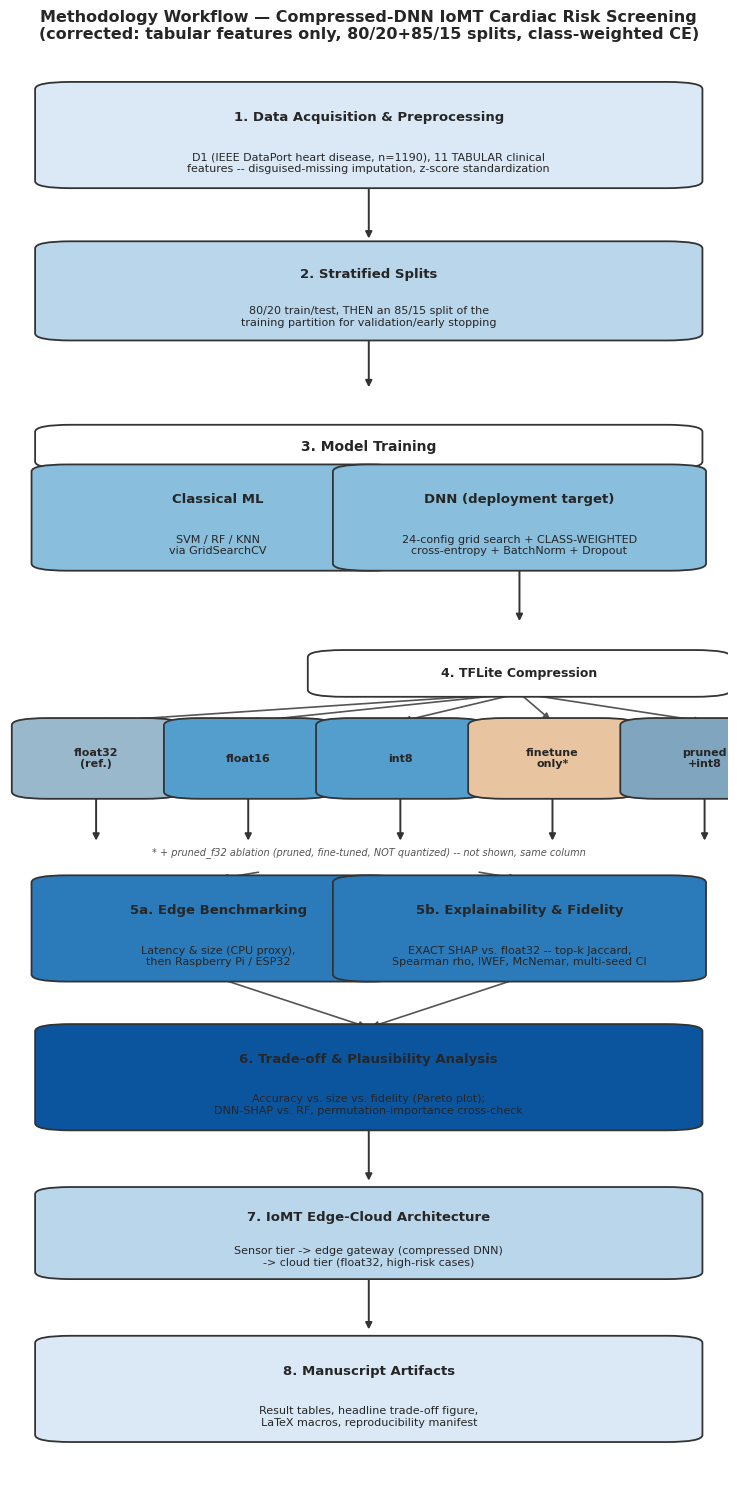

Use this as the reference for redrawing Figure_1.png -- no text/BERT/pixel/focal-loss content.


In [39]:

import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

sns.set_style("white")
sns.set_context("paper", font_scale=1.0)
palette_wf = sns.color_palette("Blues", n_colors=6)

fig, ax = plt.subplots(figsize=(7.5, 15))
ax.set_xlim(0, 10); ax.set_ylim(0, 100); ax.axis("off")


def draw_box(cx, cy, w, h, title, subtitle=None, color="#BBD6EA", fontsize=9.5, title_weight="bold"):
    x, y = cx - w / 2, cy - h / 2
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.25,rounding_size=0.5",
                          linewidth=1.3, edgecolor="#333333", facecolor=color, zorder=2)
    ax.add_patch(box)
    if subtitle:
        ax.text(cx, cy + h * 0.18, title, ha="center", va="center", fontsize=fontsize,
                 fontweight=title_weight, zorder=3)
        ax.text(cx, cy - h * 0.28, subtitle, ha="center", va="center", fontsize=fontsize - 1.5, zorder=3)
    else:
        ax.text(cx, cy, title, ha="center", va="center", fontsize=fontsize, fontweight=title_weight, zorder=3)


def v_arrow(x, y_top, y_bottom):
    ax.annotate("", xy=(x, y_bottom), xytext=(x, y_top),
                arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#333333"), zorder=1)


def diag_arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", lw=1.2, color="#555555"), zorder=1)


CX = 5.0

# Stage 1: 11 tabular clinical features, disguised-missing imputation, z-score standardization
draw_box(CX, 95, 8.8, 7, "1. Data Acquisition & Preprocessing",
          "D1 (IEEE DataPort heart disease, n=1190), 11 TABULAR clinical\n"
          "features -- disguised-missing imputation, z-score standardization",
          color=palette_wf[0])
v_arrow(CX, 91.5, 87.5)

# Stage 2: 80/20 THEN 85/15 -- explicitly both splits, correction #2
draw_box(CX, 84, 8.8, 6.5, "2. Stratified Splits",
          "80/20 train/test, THEN an 85/15 split of the\n"
          "training partition for validation/early stopping",
          color=palette_wf[1])
v_arrow(CX, 80.75, 77)

# Stage 3: training, explicit class-weighted BCE, no focal loss
draw_box(CX, 73, 8.8, 2.6, "3. Model Training", color="white", fontsize=10)
draw_box(2.9, 68, 4.7, 7, "Classical ML", "SVM / RF / KNN\nvia GridSearchCV", color=palette_wf[2])
draw_box(7.1, 68, 4.7, 7, "DNN (deployment target)",
          "24-config grid search + CLASS-WEIGHTED\ncross-entropy + BatchNorm + Dropout",
          color=palette_wf[2])
diag_arrow(CX, 71.7, 2.9, 71.5)
diag_arrow(CX, 71.7, 7.1, 71.5)
v_arrow(7.1, 64.5, 60.5)

# Stage 4: compression, 6 variants now (headline 4 + 2 ablation)
draw_box(7.1, 57, 5.4, 2.8, "4. TFLite Compression", color="white", fontsize=9)
variant_xs = [1.2, 3.32, 5.44, 7.56, 9.68]
variant_labels = ["float32\n(ref.)", "float16", "int8", "finetune\nonly*", "pruned\n+int8"]
variant_colors = ["#9AB8CC", palette_wf[3], palette_wf[3], "#E8C4A0", "#7FA6BE"]
for vx, lab, col in zip(variant_xs, variant_labels, variant_colors):
    draw_box(vx, 51, 1.85, 5.2, lab, color=col, fontsize=8)
    diag_arrow(7.1, 55.6, vx, 53.6)

for vx in variant_xs:
    v_arrow(vx, 48.4, 45)
ax.text(CX, 44.2, "* + pruned_f32 ablation (pruned, fine-tuned, NOT quantized) -- not shown, same column",
        ha="center", fontsize=7, style="italic", color="#555555")

draw_box(2.9, 39, 4.7, 7, "5a. Edge Benchmarking",
          "Latency & size (CPU proxy),\nthen Raspberry Pi / ESP32",
          color=palette_wf[4])
draw_box(7.1, 39, 4.7, 7, "5b. Explainability & Fidelity",
          "EXACT SHAP vs. float32 -- top-k Jaccard,\nSpearman rho, IWEF, McNemar, multi-seed CI",
          color=palette_wf[4])
diag_arrow(3.5, 43, 2.9, 42.5)
diag_arrow(6.5, 43, 7.1, 42.5)
diag_arrow(2.9, 35.5, CX, 32)
diag_arrow(7.1, 35.5, CX, 32)

draw_box(CX, 28.5, 8.8, 7, "6. Trade-off & Plausibility Analysis",
          "Accuracy vs. size vs. fidelity (Pareto plot);\nDNN-SHAP vs. RF, permutation-importance cross-check",
          color=palette_wf[5])
v_arrow(CX, 25, 21)

draw_box(CX, 17.5, 8.8, 6, "7. IoMT Edge-Cloud Architecture",
          "Sensor tier -> edge gateway (compressed DNN)\n-> cloud tier (float32, high-risk cases)",
          color=palette_wf[1])
v_arrow(CX, 14.5, 10.5)

draw_box(CX, 6.5, 8.8, 7, "8. Manuscript Artifacts",
          "Result tables, headline trade-off figure,\nLaTeX macros, reproducibility manifest",
          color=palette_wf[0])

ax.set_title("Methodology Workflow — Compressed-DNN IoMT Cardiac Risk Screening\n"
             "(corrected: tabular features only, 80/20+85/15 splits, class-weighted CE)",
             fontsize=11.5, fontweight="bold", pad=18)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/methodology_workflow.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUT_DIR}/methodology_workflow.pdf", bbox_inches="tight")
plt.show()
print("Use this as the reference for redrawing Figure_1.png -- no text/BERT/pixel/focal-loss content.")


---
# 15. Seven-panel synthesis figure (matches the paper's Figure 2)

Panel (E) is now built from the exact same `tradeoff_df` as Table 1 and Section 11 (correction #6) —
no more silently-stale numbers or a mystery extra variant.


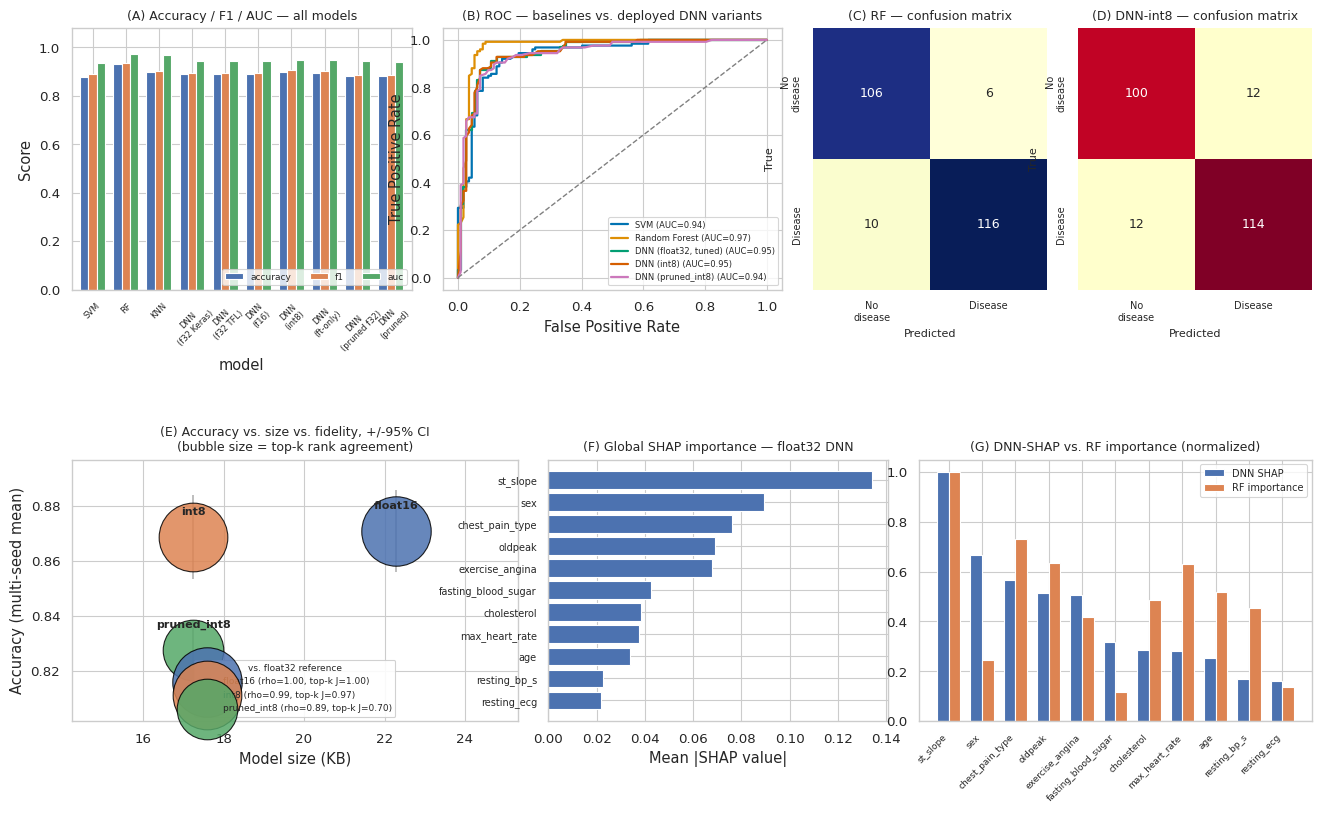

Sanity check -- Panel E sizes/accuracies MUST equal Table 1 / tradeoff_table.csv:
               size_kb  accuracy  spearman_mean  topk_jaccard_mean
variant                                                           
float16      22.285156  0.871008       0.999931           0.999440
int8         17.250000  0.868908       0.992422           0.971854
pruned_int8  17.250000  0.827731       0.885535           0.701160


In [40]:

from sklearn.metrics import auc  # needed for Panel B's AUC-in-legend computation below

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 24, figure=fig, hspace=0.65, wspace=1.4)

ax_a = fig.add_subplot(gs[0, 0:7])
short_labels = {
    "SVM": "SVM", "Random Forest": "RF", "KNN": "KNN",
    "DNN (float32, Keras, tuned)": "DNN\n(f32 Keras)",
    "DNN (float32, TFLite)": "DNN\n(f32 TFL)",
    "DNN (float16, TFLite)": "DNN\n(f16)",
    "DNN (int8, TFLite)": "DNN\n(int8)",
    "DNN (finetune_only, TFLite)": "DNN\n(ft-only)",
    "DNN (pruned_f32, TFLite)": "DNN\n(pruned f32)",
    "DNN (pruned_int8, TFLite)": "DNN\n(pruned)",
}
plot_a = compressed_results_df[["accuracy", "f1", "auc"]].rename(index=short_labels)
plot_a.plot(kind="bar", ax=ax_a, width=0.75, color=["#4C72B0", "#DD8452", "#55A868"])
ax_a.set_title("(A) Accuracy / F1 / AUC — all models", fontsize=9)
ax_a.set_ylabel("Score"); ax_a.set_ylim(0, 1.08)
ax_a.tick_params(axis="x", rotation=45, labelsize=6)
ax_a.legend(fontsize=6.5, loc="lower right", ncol=3)

ax_b = fig.add_subplot(gs[0, 7:14])
roc_models = {
    "SVM": svm_best.predict_proba(X_test)[:, 1],
    "Random Forest": rf_best.predict_proba(X_test)[:, 1],
    "DNN (float32, tuned)": y_proba_dnn,
    "DNN (int8)": tflite_predict(interpreters["int8"], X_test),
    "DNN (pruned_int8)": tflite_predict(interpreters["pruned_int8"], X_test),
}
palette_roc = sns.color_palette("colorblind", n_colors=len(roc_models))
for (name, proba), color in zip(roc_models.items(), palette_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_b.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})", color=color, linewidth=1.6)
ax_b.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax_b.set_title("(B) ROC — baselines vs. deployed DNN variants", fontsize=9)
ax_b.set_xlabel("False Positive Rate"); ax_b.set_ylabel("True Positive Rate")
ax_b.legend(fontsize=6, loc="lower right")

ax_c = fig.add_subplot(gs[0, 14:19])
cm_rf = confusion_matrix(y_test, rf_best.predict(X_test))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="YlGnBu", cbar=False, ax=ax_c,
            xticklabels=["No\ndisease", "Disease"], yticklabels=["No\ndisease", "Disease"],
            annot_kws={"fontsize": 9})
ax_c.set_title("(C) RF — confusion matrix", fontsize=9)
ax_c.set_xlabel("Predicted", fontsize=8); ax_c.set_ylabel("True", fontsize=8)
ax_c.tick_params(labelsize=7)

ax_d = fig.add_subplot(gs[0, 19:24])
pred_int8 = (tflite_predict(interpreters["int8"], X_test) >= 0.5).astype(int)
cm_int8 = confusion_matrix(y_test, pred_int8)
assert cm_int8.sum() == len(X_test)
sns.heatmap(cm_int8, annot=True, fmt="d", cmap="YlOrRd", cbar=False, ax=ax_d,
            xticklabels=["No\ndisease", "Disease"], yticklabels=["No\ndisease", "Disease"],
            annot_kws={"fontsize": 9})
ax_d.set_title("(D) DNN-int8 — confusion matrix", fontsize=9)
ax_d.set_xlabel("Predicted", fontsize=8); ax_d.set_ylabel("True", fontsize=8)
ax_d.tick_params(labelsize=7)

# --- Panel E: EXACTLY the headline (non-ablation) rows of tradeoff_df / Table 1 (correction #6) ---
ax_e = fig.add_subplot(gs[1, 0:9])
plot_e = tradeoff_df[~tradeoff_df["is_ablation"]].dropna(subset=["size_kb"])
plot_e = plot_e.loc[[v for v in ["float16", "int8", "pruned_int8"] if v in plot_e.index]]
variant_colors = {"float16": "#4C72B0", "int8": "#DD8452", "pruned_int8": "#55A868"}

for variant, row in plot_e.iterrows():
    size = 500 + 2000 * row["topk_jaccard_mean"]
    ax_e.errorbar(row["size_kb"], row["accuracy"], yerr=row["accuracy_ci"],
                  fmt="none", ecolor="gray", alpha=0.6, zorder=2)
    ax_e.scatter(row["size_kb"], row["accuracy"], s=size, color=variant_colors.get(variant, "gray"),
                 edgecolor="k", alpha=0.85, zorder=3,
                 label=f"{variant} (rho={row['spearman_mean']:.2f}, top-k J={row['topk_jaccard_mean']:.2f})")
    ax_e.annotate(variant, (row["size_kb"], row["accuracy"]),
                  textcoords="offset points", xytext=(0, 16), fontsize=8, ha="center", fontweight="bold")

x_span = plot_e["size_kb"].max() - plot_e["size_kb"].min()
y_span = plot_e["accuracy"].max() - plot_e["accuracy"].min()
ax_e.set_xlim(plot_e["size_kb"].min() - max(x_span * 0.6, 0.4), plot_e["size_kb"].max() + max(x_span * 0.6, 0.4))
ax_e.set_ylim(plot_e["accuracy"].min() - max(y_span * 0.6, 0.01), plot_e["accuracy"].max() + max(y_span * 0.6, 0.01))
ax_e.set_title("(E) Accuracy vs. size vs. fidelity, +/-95% CI\n(bubble size = top-k rank agreement)", fontsize=9)
ax_e.set_xlabel("Model size (KB)"); ax_e.set_ylabel("Accuracy (multi-seed mean)")
ax_e.legend(fontsize=6.5, loc="lower center", title="vs. float32 reference", title_fontsize=6.5, framealpha=0.9)

ax_f = fig.add_subplot(gs[1, 9:16])
mean_abs_shap = np.abs(shap_values["float32"]).mean(axis=0)
order = np.argsort(mean_abs_shap)
ax_f.barh(np.array(FEATURES)[order], mean_abs_shap[order], color="#4C72B0")
ax_f.set_title("(F) Global SHAP importance — float32 DNN", fontsize=9)
ax_f.set_xlabel("Mean |SHAP value|")
ax_f.tick_params(axis="y", labelsize=7)

ax_g = fig.add_subplot(gs[1, 16:24])
comp = importance_compare.sort_values("shap_rank")
x = np.arange(len(comp)); width = 0.35
ax_g.bar(x - width/2, comp["mean_abs_shap"] / comp["mean_abs_shap"].max(), width, label="DNN SHAP", color="#4C72B0")
ax_g.bar(x + width/2, comp["rf_importance"] / comp["rf_importance"].max(), width, label="RF importance", color="#DD8452")
ax_g.set_xticks(x); ax_g.set_xticklabels(comp.index, rotation=45, ha="right", fontsize=6.5)
ax_g.set_title("(G) DNN-SHAP vs. RF importance (normalized)", fontsize=9)
ax_g.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/paper_results_figure_7panel.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUT_DIR}/paper_results_figure_7panel.pdf", bbox_inches="tight")
plt.show()

print("Sanity check -- Panel E sizes/accuracies MUST equal Table 1 / tradeoff_table.csv:")
print(plot_e[["size_kb", "accuracy", "spearman_mean", "topk_jaccard_mean"]])


---
# 16. System architecture (for the paper's Section 3)

This notebook validates the **model layer** of the following three-tier IoMT architecture. It does not
claim the dataset is live sensor data — say this explicitly in the paper.

```
[ Wearable / bedside sensor tier ]
        |  (vitals: HR, BP, etc. -- represented here by D1's clinical features)
        v
[ Edge gateway -- e.g. Raspberry Pi / ESP32-class ]
        - runs the compressed DNN (float16 or int8, per Section 12's uncertainty-aware selection)
        - low-latency, offline-capable risk score
        - flags high-risk cases
        v (only if flagged)
[ Cloud tier ]
        - full-precision float32 model for confirmatory / high-stakes inference
        - can afford full SHAP explanation for clinician review
```

**Correction #21 — honesty in Motivation:** the float32 MLP here is small enough to fit on many MCU-class
devices too, so "compression is required to fit at all" is not, by itself, the strongest argument for
int8. The stronger, honest argument is that int8 enables **integer-only inference on FPU-less low-power
MCUs**, and that D1 is used here as a **controlled testbed** to isolate the compression/explainability
question — not a claim that this exact model needed compression to physically fit anywhere. State this
in the Motivation paragraph rather than implying float32 wouldn't fit.

**Recommendation to state in the Discussion:** pick the variant from Section 12's uncertainty-aware
Algorithm 1 (lower-confidence-bound selection) whose fidelity stays above the clinically acceptable
threshold at that bound, not simply the smallest/fastest one.


---
# 17. Deploying to real edge hardware (Raspberry Pi / ESP32) — run this OUTSIDE Colab

CPU-only numbers in this notebook are **not** a substitute for real edge-hardware numbers in the paper.
The cell below is **not meant to run in Colab**; copy it into a `.py` file on the device itself.

**Raspberry Pi (any model, Raspberry Pi OS):**
```bash
pip install tflite-runtime numpy
# copy dnn_float16.tflite, dnn_int8.tflite, dnn_finetune_only.tflite, dnn_pruned_f32.tflite, and
# dnn_pruned_int8.tflite from this notebook's outputs/tflite_models/ to the Pi
```

```python
# deploy_pi_benchmark.py -- run this ON the Raspberry Pi, not in Colab
import time
import numpy as np
from tflite_runtime.interpreter import Interpreter

MODEL_PATH = "dnn_int8.tflite"   # or dnn_float16.tflite / dnn_pruned_int8.tflite / etc.
N_RUNS = 200

interpreter = Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

X_test = np.load("X_test.npy").astype(np.float32)
in_scale, in_zero = input_details["quantization"]

def predict_one(x):
    if input_details["dtype"] in (np.int8, np.uint8):
        x = (x / in_scale + in_zero).round().astype(input_details["dtype"])
    else:
        x = x.astype(input_details["dtype"])
    interpreter.set_tensor(input_details["index"], x.reshape(1, -1))
    interpreter.invoke()
    return interpreter.get_tensor(output_details["index"])

sample = X_test[:1]
for _ in range(10):
    predict_one(sample)  # warmup

times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    predict_one(sample)
    times.append((time.perf_counter() - t0) * 1000)

print(f"Mean latency: {np.mean(times):.3f} ms  (std {np.std(times):.3f} ms)")
print(f"Model size: {__import__('os').path.getsize(MODEL_PATH) / 1024:.1f} KB")
```

**ESP32 (via TensorFlow Lite for Microcontrollers):** convert the `.tflite` int8 model to a C byte array
(`xxd -i dnn_int8.tflite > model_data.cc`) and compile it into an Arduino/ESP-IDF sketch using
`tflite-micro`. Heavier lift than the Pi route — only do it if the paper specifically needs
microcontroller-class numbers.


In [41]:

np.save(f"{OUT_DIR}/X_test.npy", X_test)
np.save(f"{OUT_DIR}/y_test.npy", y_test)
print("Exported X_test.npy / y_test.npy to", OUT_DIR)
print("Copy these plus the .tflite files in", TFLITE_DIR, "onto the target device.")


Exported X_test.npy / y_test.npy to /content/outputs
Copy these plus the .tflite files in /content/outputs/tflite_models onto the target device.


---
## 18.1 Reproducibility manifest

Updated with every new setting introduced by this revision (exact SHAP, N_SEEDS, sparsity sweep, dedup
sensitivity, IWEF normalization method, tier-selection rule) so a co-author or reviewer can see exactly
which configuration produced the numbers in the PDF.


In [42]:

manifest = {
    "random_state": RANDOM_STATE,
    "run_mode": RUN_MODE,
    "n_seeds_fidelity_variance": N_SEEDS,
    "seed_list": SEED_LIST,
    "dedup_n_seeds": DEDUP_N_SEEDS,
    "dataset_url": D1_URL,
    "dataset_md5": dataset_md5,
    "dataset_shape": list(df_heart_disease.shape),
    "dataset_n_exact_duplicates": int(n_dupes),
    "best_dnn_config": best_config,
    "dnn_grid_search_size": len(DNN_SEARCH_SPACE),
    "pruning_target_sparsity": PRUNING_TARGET_SPARSITY,
    "pruning_sparsity_sweep": SPARSITY_SWEEP,
    "pruning_epochs": PRUNING_EPOCHS,
    "achieved_pruning_sparsity": achieved_sparsity,
    "shap_algorithm": "exact",
    "shap_background_size": SHAP_BACKGROUND_SIZE,
    "shap_test_subset_size": len(X_shap_subset),
    "shap_used_full_test_set": SHAP_TEST_SUBSET is None,
    "top_k_fidelity": TOP_K,
    "tflite_batch_size": TFLITE_BATCH_SIZE,
    "ablation_variants": ABLATION_VARIANTS,
    "headline_compressed_variants": COMPRESSED_VARIANTS,
    "iwef_normalization": "tight (per-sample max-weight assignment via linear_sum_assignment)",
    "clinical_weight_override_used": CLINICAL_WEIGHT_OVERRIDE is not None,
    "tier_selection_rule": "lower_confidence_bound",
    "tau_fidelity": TAU_FIDELITY,
    "tau_accuracy": TAU_ACCURACY,
    "tf_op_determinism_enabled": True,
    "library_versions": {
        "tensorflow": tf.__version__,
        "shap": shap.__version__,
        "python": platform.python_version(),
    },
}
with open(f"{OUT_DIR}/reproducibility_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
manifest


{'random_state': 42,
 'run_mode': 'full',
 'n_seeds_fidelity_variance': 10,
 'seed_list': [42, 43, 44, 45, 46, 47, 48, 49, 50, 51],
 'dedup_n_seeds': 5,
 'dataset_url': 'https://raw.githubusercontent.com/erdenahmet11/Heart-Disease-Prediction/master/heart_statlog_cleveland_hungary_final.csv',
 'dataset_md5': '89331abbd1786b4942ab8c588b832d39',
 'dataset_shape': [1190, 12],
 'dataset_n_exact_duplicates': 272,
 'best_dnn_config': {'hidden_units': (128, 64), 'dropout': 0.2, 'lr': 0.001},
 'dnn_grid_search_size': 24,
 'pruning_target_sparsity': 0.5,
 'pruning_sparsity_sweep': [0.3, 0.5, 0.7, 0.9],
 'pruning_epochs': 10,
 'achieved_pruning_sparsity': 0.49583481297348486,
 'shap_algorithm': 'exact',
 'shap_background_size': 50,
 'shap_test_subset_size': 238,
 'shap_used_full_test_set': True,
 'top_k_fidelity': 5,
 'tflite_batch_size': 256,
 'ablation_variants': ['finetune_only', 'pruned_f32', 'int8', 'pruned_int8'],
 'headline_compressed_variants': ['float16', 'int8', 'pruned_int8'],
 'iwef_n

---
# 19. Summary of exported artifacts

Everything below is written to `OUT_DIR` (`/content/outputs` on Colab, `./outputs` locally).

| File | Used for |
|---|---|
| `baseline_model_comparison.csv` | SVM/RF/KNN/tuned-DNN(float32) comparison |
| `dnn_hyperparam_search_24config.csv` | Full 24-config DNN grid search log (correction #9c) |
| `all_model_comparison.csv` | Adds float16/int8/pruned_int8/ablation TFLite rows |
| `mcnemar_significance.csv` | Paired significance test vs. float32 (correction #8) |
| `latency_size_benchmark_cpu_proxy.csv` | CPU-proxy latency/size — replace with Pi numbers for the paper |
| `compression_sweep_sparsity.csv` | Sparsity {0.3,0.5,0.7,0.9} sweep, incl. gzip size (correction #18) |
| `confusion_matrices_and_roc.png` | Appendix figure, all models, all 5 DNN variants (correction #5) |
| `explanation_fidelity_single_run.csv` | Single-split fidelity incl. the noise-floor row (correction #0) |
| `theory_bound_check.csv` | Shapley-linearity rank-swap bound check (correction #16) |
| `second_explainer_permutation_importance.csv` | Cross-check vs. SHAP (correction #20) |
| `shap_vs_rf_feature_importance.csv` | Clinical-plausibility cross-check |
| `fidelity_variance_across_seeds.csv`, `fidelity_variance_summary.csv` | Multi-seed (N=`N_SEEDS`) fidelity + CI |
| `dedup_sensitivity_seeds.csv`, `dedup_sensitivity_summary.csv` | Dedup sensitivity analysis (correction #10) |
| `paired_wilcoxon_fidelity.csv` | Paired significance between variants' fidelity (correction #13) |
| `tier_selection.json` | Uncertainty-aware Algorithm 1 output (correction #13) |
| `table1_final.csv` | The exact numbers behind the paper's Table 1 |
| `paper_macros.tex` | **`\input` this into the manuscript** — the single source of truth (correction #3) |
| `tradeoff_table.csv`, `tradeoff_3way.png/.pdf` | The paper's headline trade-off figure (correction #6) |
| `paper_results_figure_7panel.png/.pdf` | The paper's Figure 2 |
| `methodology_workflow.png/.pdf` | Corrected pipeline diagram (correction #2) |
| `reproducibility_manifest.json` | Exact config + versions behind this run |
| `X_test.npy`, `y_test.npy` | Hand off to the Raspberry Pi / ESP32 script |


In [43]:

import zipfile

zip_path = "/content/outputs.zip" if os.path.isdir("/content") else "./outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(OUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, OUT_DIR)
            zf.write(full_path, arcname)

print("Zipped outputs to", zip_path)

try:
    from google.colab import files as colab_files
    colab_files.download(zip_path)
except ImportError:
    print("Not running in Colab -- find the zip at", zip_path)


Zipped outputs to /content/outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>